<a href="https://colab.research.google.com/github/negidiya287/DS-assignment2/blob/main/DS_ass3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded=files.upload()
print(uploaded)

In [ ]:
#  IMPORT REQUIRED LIBRARIES
# Pandas for data loading, cleaning, and analysis
import pandas as pd

# NumPy for numerical operations
import numpy as np

# Matplotlib for plotting
import matplotlib.pyplot as plt

# Seaborn for advanced statistical visualizations
import seaborn as sns

# Warnings to suppress unnecessary warning messages for cleaner notebook output
import warnings
warnings.filterwarnings('ignore')

# Set consistent visual style for all plots
plt.style.use('ggplot')
sns.set(style='whitegrid')

print("Libraries imported successfully.")
from wordcloud import WordCloud
import missingno as msno

Libraries imported successfully.


In [ ]:
# 2. LOAD DATASET SAFELY (EXCEPTION HANDLING)
# NOTE:
# Upload "Global Terrorism Data.csv" to Colab before running this cell.

file_name = 'Global Terrorism Data.csv'

try:
    # low_memory=False avoids mixed dtype warnings in large CSVs
    df = pd.read_csv(file_name, encoding='latin1', low_memory=False)
    print(f"Dataset loaded successfully from file: {file_name}")
    print(f"Dataset Shape: {df.shape}")
except FileNotFoundError:
    print(f"ERROR: File '{file_name}' not found.")
    print("Please upload the dataset to Colab and ensure the file name is correct.")
    raise
except pd.errors.EmptyDataError:
    print("ERROR: The CSV file is empty.")
    raise
except Exception as e:
    print(f"Unexpected error while loading dataset: {e}")
    raise

Dataset loaded successfully from file: Global Terrorism Data.csv
Dataset Shape: (181691, 135)


Dataset First View AND Dataset Rows & Columns count

In [ ]:
# BASIC DATA UNDERSTANDING & VALIDATION

# Display first 5 rows to understand structure
display(df.head())

# Basic dataset dimensions
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

# Display concise information about columns and data types
print("\nDataset Information:\n")
df.info()

# Check if required columns exist before proceeding
required_cols = [
    'iyear', 'imonth', 'iday',
    'country_txt', 'region_txt', 'city',
    'attacktype1_txt', 'targtype1_txt',
    'weaptype1_txt', 'gname',
    'nkill', 'nwound',
    'property', 'success'
]

missing_required_cols = [col for col in required_cols if col not in df.columns]

if missing_required_cols:
    print("\nERROR: Some required columns are missing from the dataset:")
    print(missing_required_cols)
    raise ValueError("Required columns missing. Please verify the dataset.")
else:
    print("\nAll required columns are present. Safe to proceed.")

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN


Number of Rows: 181691
Number of Columns: 135

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Columns: 135 entries, eventid to related
dtypes: float64(55), int64(22), object(58)
memory usage: 187.1+ MB

All required columns are present. Safe to proceed.


Dataset Information

In [ ]:
# CHECKING MISSING / NULL VALUES

# Count total missing values in each column
missing_values = df.isnull().sum()

# Display columns having missing values greater than 0
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print("Columns with Missing / Null Values:")
display(missing_values)

# Total number of missing values in the entire dataset
total_missing = df.isnull().sum().sum()
print("Total Missing Values in Dataset:", total_missing)


Columns with Missing / Null Values:


,0
gsubname3,181671
weapsubtype4_txt,181621
weapsubtype4,181621
weaptype4_txt,181618
weaptype4,181618
...,...
guncertain1,380
ishostkid,178
specificity,6
multiple,1


Total Missing Values in Dataset: 13854004


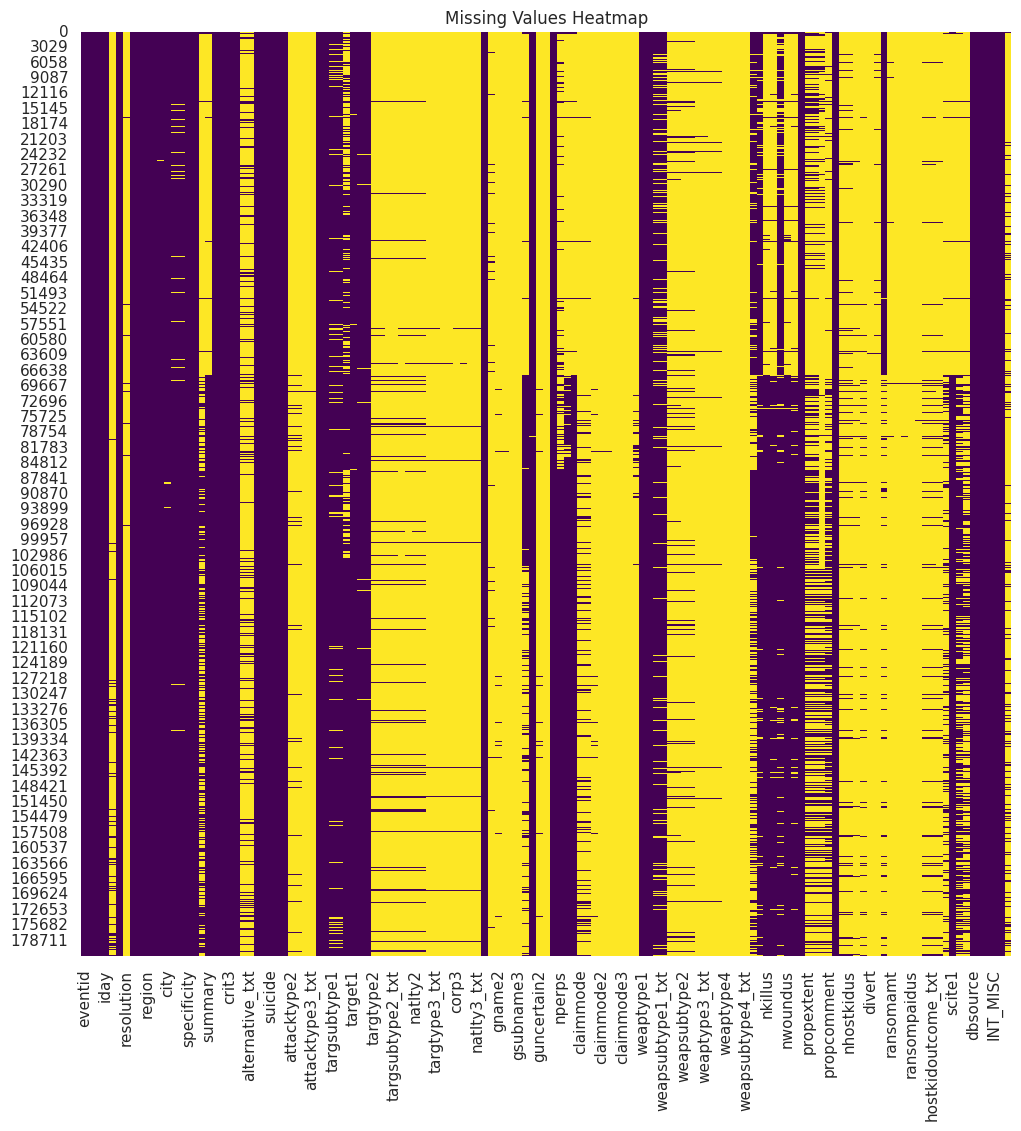

In [ ]:
# Visualizing the missing values
plt.figure(figsize=(12,12))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()


Missing Value Observation
The original dataset contains 135 columns, many of which are not required for this EDA objective. To keep the analysis focused, only the most relevant columns are selected. Missing values will be handled logically depending on whether the feature is categorical or numerical.

What did you know about your dataset?
The Global Terrorism Dataset is a large historical dataset containing 181,691 terrorist incidents recorded worldwide from 1970 to 2017. It includes 135 columns with details such as date, country, region, city, attack type, target type, weapon type, terrorist group, casualties, property damage, and success of the attack. This makes it highly suitable for EDA-based analysis to understand global terrorism trends and patterns. Here are the key characteristics identified so far:

Shape: The dataset contains 112,550 rows and 135 columns. Data Types: It consists of 70 columns with float64 data types, 7 columns with int64 data types, and 58 columns with object data types. Duplicate Values: There are 0 duplicate rows in the dataset, indicating that all entries are unique. Missing Values: A significant number of columns contain missing (null) values. Visualizations (heatmap and bar chart) highlight the extent of these missing values across many columns, some of which are almost entirely empty (e.g., approxdate, related, scite1, scite2, scite3). Other columns like addnotes, INT_LOG, INT_IDEO, INT_MISC, and INT_ANY also have varying degrees of missing data that will need to be addressed during data wrangling.

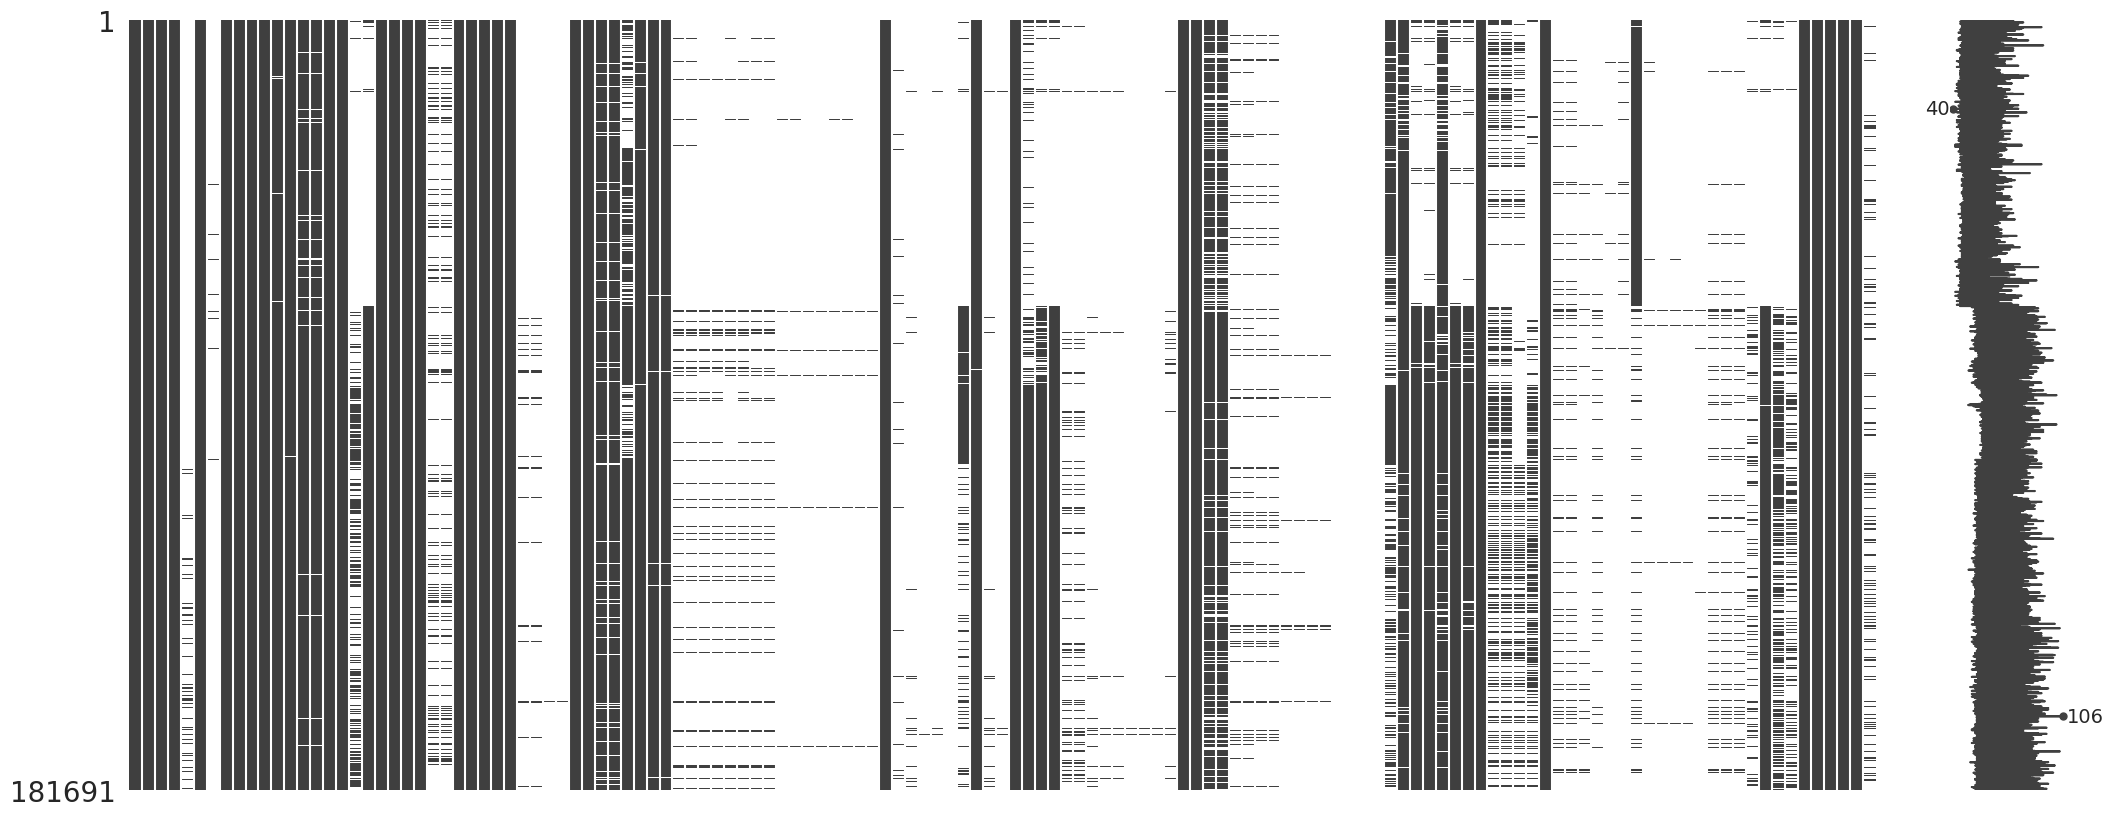

In [ ]:
msno.matrix(df)
plt.show()


<Axes: >

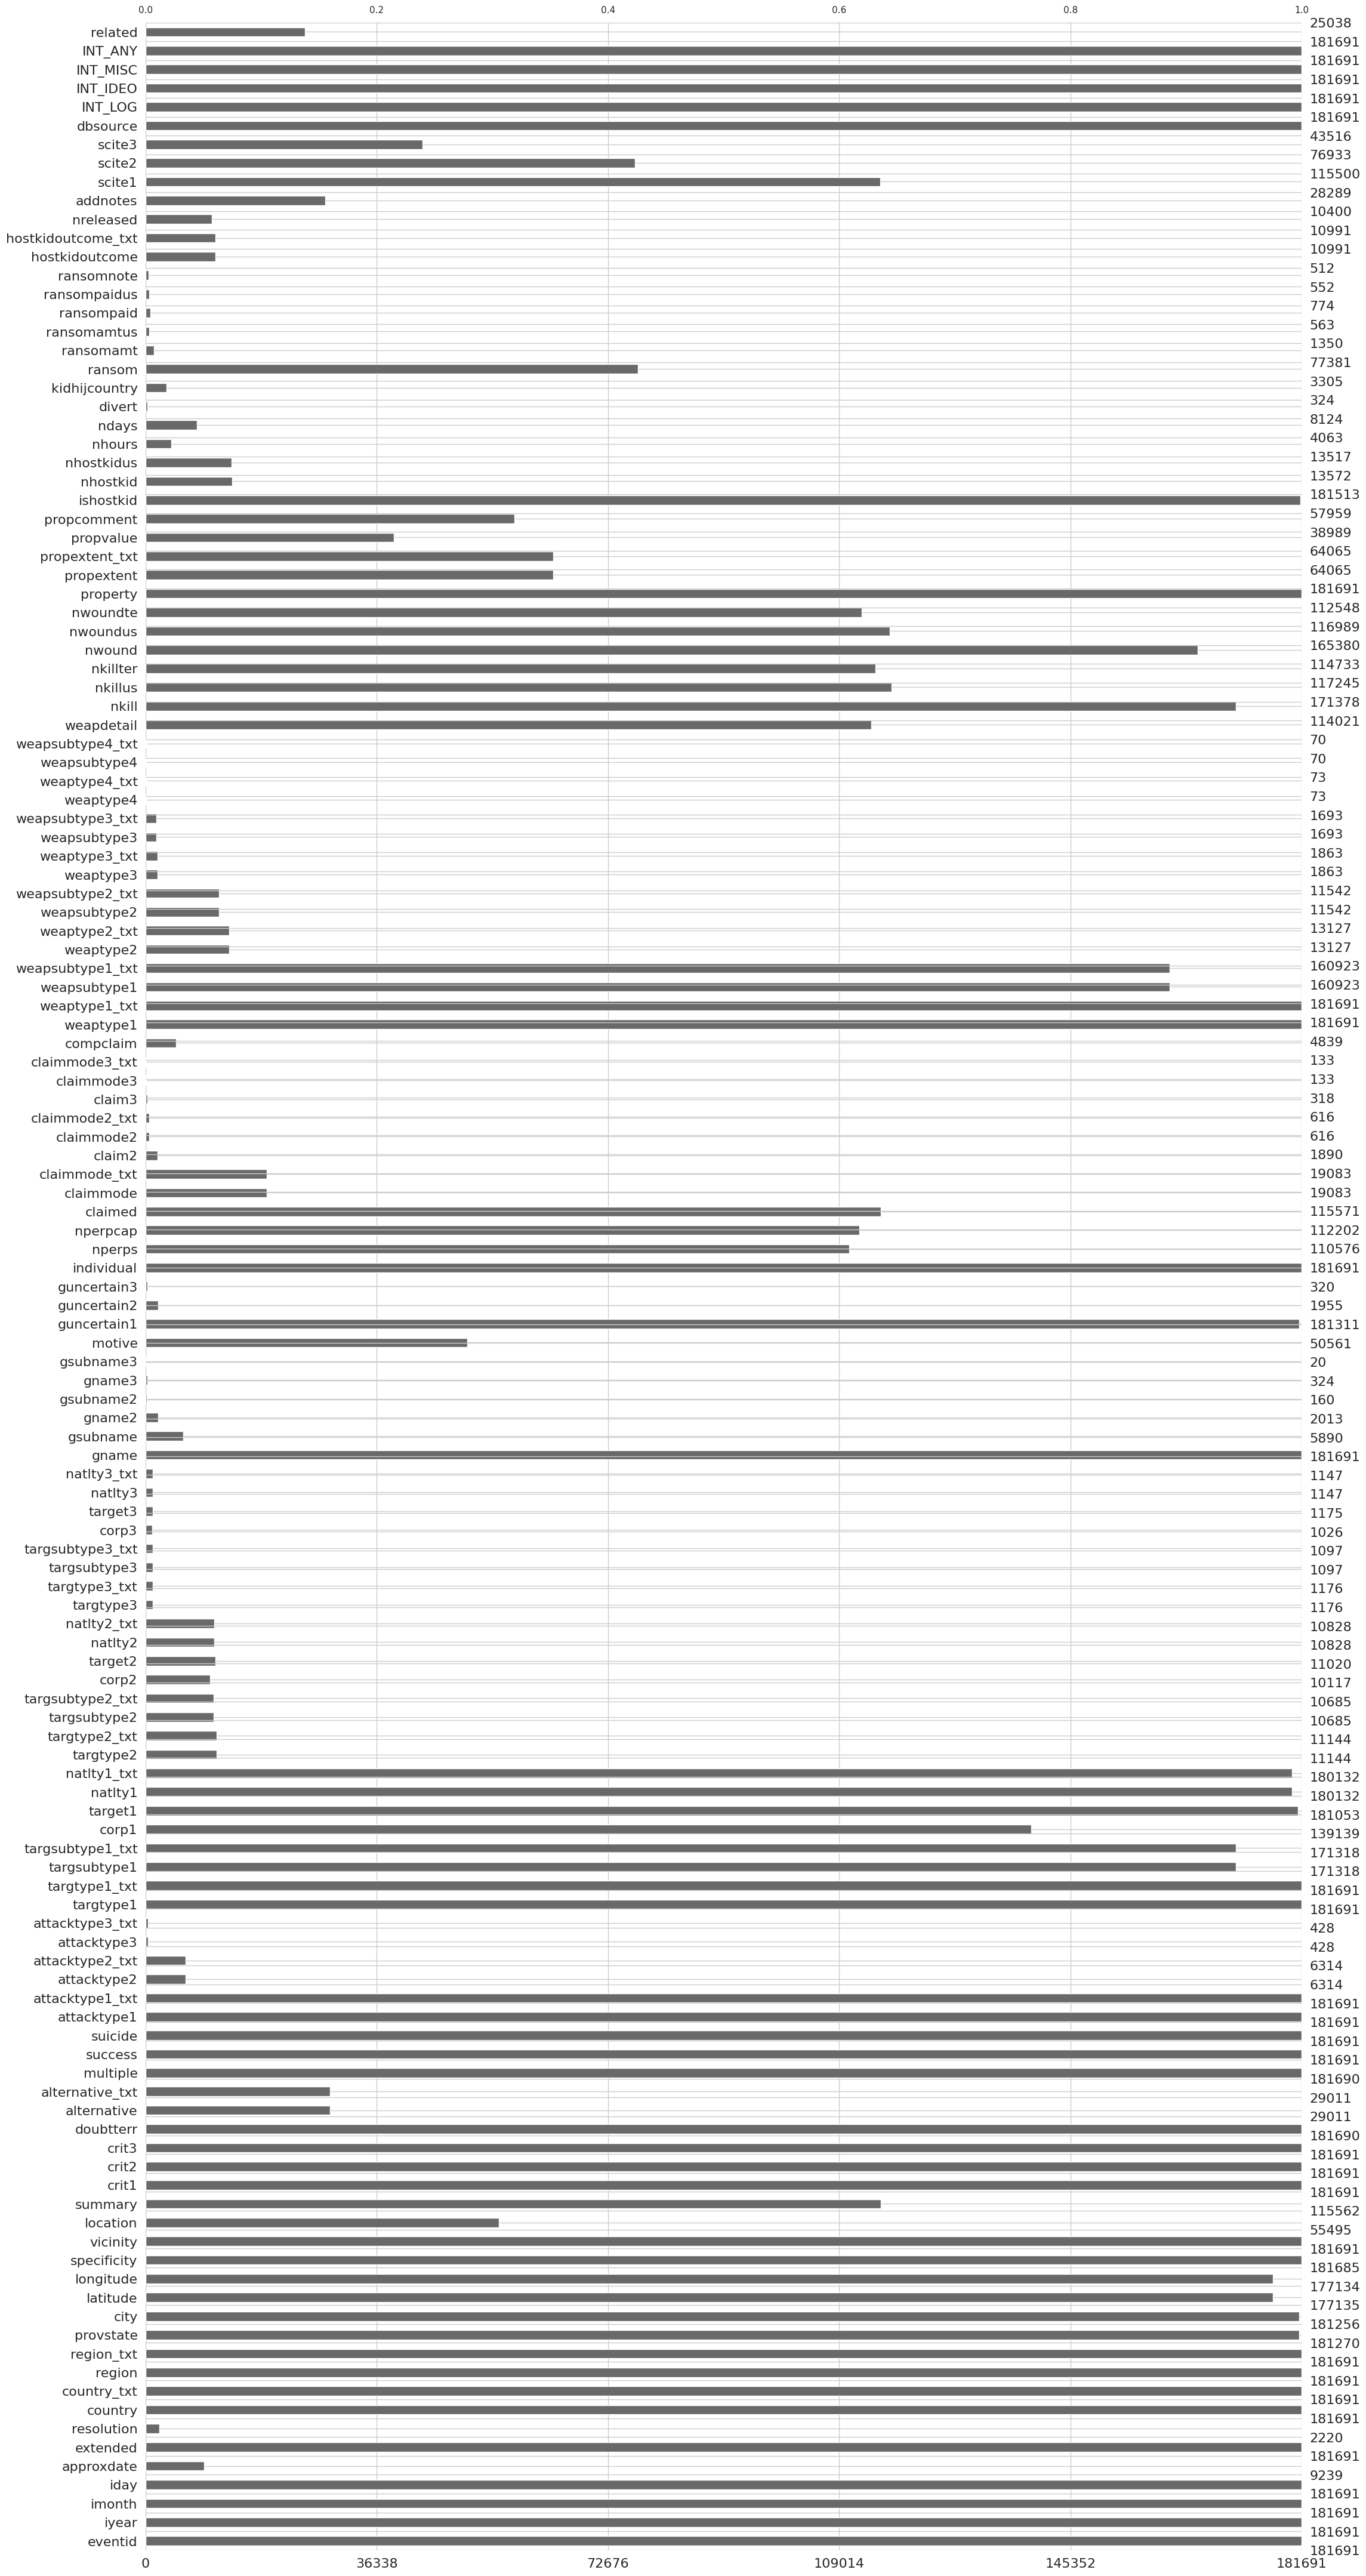

In [ ]:

msno.bar(df)

2. Understanding Your Variables


In [ ]:
# DATASET COLUMNS

# Display all column names in the dataset
print("Total Number of Columns:", len(df.columns))
print("\nColumn Names in the Dataset:\n")
print(df.columns.tolist())


Total Number of Columns: 135

Column Names in the Dataset:

['eventid', 'iyear', 'imonth', 'iday', 'approxdate', 'extended', 'resolution', 'country', 'country_txt', 'region', 'region_txt', 'provstate', 'city', 'latitude', 'longitude', 'specificity', 'vicinity', 'location', 'summary', 'crit1', 'crit2', 'crit3', 'doubtterr', 'alternative', 'alternative_txt', 'multiple', 'success', 'suicide', 'attacktype1', 'attacktype1_txt', 'attacktype2', 'attacktype2_txt', 'attacktype3', 'attacktype3_txt', 'targtype1', 'targtype1_txt', 'targsubtype1', 'targsubtype1_txt', 'corp1', 'target1', 'natlty1', 'natlty1_txt', 'targtype2', 'targtype2_txt', 'targsubtype2', 'targsubtype2_txt', 'corp2', 'target2', 'natlty2', 'natlty2_txt', 'targtype3', 'targtype3_txt', 'targsubtype3', 'targsubtype3_txt', 'corp3', 'target3', 'natlty3', 'natlty3_txt', 'gname', 'gsubname', 'gname2', 'gsubname2', 'gname3', 'gsubname3', 'motive', 'guncertain1', 'guncertain2', 'guncertain3', 'individual', 'nperps', 'nperpcap', 'claimed', 

In [ ]:
# DATASET DESCRIPTION (NUMERICAL COLUMNS)

# Summary statistics for numerical columns
df.describe()

,eventid,iyear,imonth,iday,extended,country,region,latitude,longitude,specificity,...,ransomamt,ransomamtus,ransompaid,ransompaidus,hostkidoutcome,nreleased,INT_LOG,INT_IDEO,INT_MISC,INT_ANY
count,1.816910e+05,181691.000000,181691.000000,181691.000000,181691.000000,181691.000000,181691.000000,177135.000000,1.771340e+05,181685.000000,...,1.350000e+03,5.630000e+02,7.740000e+02,552.000000,10991.000000,10400.000000,181691.000000,181691.000000,181691.000000,181691.000000
mean,2.002705e+11,2002.638997,6.467277,15.505644,0.045346,131.968501,7.160938,23.498343,-4.586957e+02,1.451452,...,3.172530e+06,5.784865e+05,7.179437e+05,240.378623,4.629242,-29.018269,-4.543731,-4.464398,0.090010,-3.945952
std,1.325957e+09,13.259430,3.388303,8.814045,0.208063,112.414535,2.933408,18.569242,2.047790e+05,0.995430,...,3.021157e+07,7.077924e+06,1.014392e+07,2940.967293,2.035360,65.720119,4.543547,4.637152,0.568457,4.691325
min,1.970000e+11,1970.000000,0.000000,0.000000,0.000000,4.000000,1.000000,-53.154613,-8.618590e+07,1.000000,...,-9.900000e+01,-9.900000e+01,-9.900000e+01,-99.000000,1.000000,-99.000000,-9.000000,-9.000000,-9.000000,-9.000000
25%,1.991021e+11,1991.000000,4.000000,8.000000,0.000000,78.000000,5.000000,11.510046,4.545640e+00,1.000000,...,0.000000e+00,0.000000e+00,-9.900000e+01,0.000000,2.000000,-99.000000,-9.000000,-9.000000,0.000000,-9.000000
50%,2.009022e+11,2009.000000,6.000000,15.000000,0.000000,98.000000,6.000000,31.467463,4.324651e+01,1.000000,...,1.500000e+04,0.000000e+00,0.000000e+00,0.000000,4.000000,0.000000,-9.000000,-9.000000,0.000000,0.000000
75%,2.014081e+11,2014.000000,9.000000,23.000000,0.000000,160.000000,10.000000,34.685087,6.871033e+01,1.000000,...,4.000000e+05,0.000000e+00,1.273412e+03,0.000000,7.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,2.017123e+11,2017.000000,12.000000,31.000000,1.000000,1004.000000,12.000000,74.633553,1.793667e+02,5.000000,...,1.000000e+09,1.320000e+08,2.750000e+08,48000.000000,7.000000,2769.000000,1.000000,1.000000,1.000000,1.000000


Check Unique Values for each variable.

In [ ]:
# CHECK UNIQUE VALUES FOR EACH SELECTED VARIABLE

# List of important columns used in the project
important_cols = [
    'iyear', 'imonth', 'iday',
    'country_txt', 'region_txt', 'city',
    'attacktype1_txt', 'targtype1_txt',
    'weaptype1_txt', 'gname',
    'nkill', 'nwound',
    'property', 'success'
]

# Display number of unique values in each selected column
for col in important_cols:
    print(f"{col} --> {df[col].nunique()} unique values")


iyear --> 47 unique values
imonth --> 13 unique values
iday --> 32 unique values
country_txt --> 205 unique values
region_txt --> 12 unique values
city --> 36673 unique values
attacktype1_txt --> 9 unique values
targtype1_txt --> 22 unique values
weaptype1_txt --> 12 unique values
gname --> 3537 unique values
nkill --> 205 unique values
nwound --> 238 unique values
property --> 3 unique values
success --> 2 unique values


3. Data Wrangling
Data Wrangling Code

In [ ]:
# 5. SELECT IMPORTANT COLUMNS FOR ANALYSIS
# Create a copy of only the important columns to keep the analysis focused and efficient
terror_df = df[required_cols].copy()

print("Selected analysis dataset shape:", terror_df.shape)
display(terror_df.head())


Selected analysis dataset shape: (181691, 14)


,iyear,imonth,iday,country_txt,region_txt,city,attacktype1_txt,targtype1_txt,weaptype1_txt,gname,nkill,nwound,property,success
0,1970,7,2,Dominican Republic,Central America & Caribbean,Santo Domingo,Assassination,Private Citizens & Property,Unknown,MANO-D,1.0,0.0,0,1
1,1970,0,0,Mexico,North America,Mexico city,Hostage Taking (Kidnapping),Government (Diplomatic),Unknown,23rd of September Communist League,0.0,0.0,0,1
2,1970,1,0,Philippines,Southeast Asia,Unknown,Assassination,Journalists & Media,Unknown,Unknown,1.0,0.0,0,1
3,1970,1,0,Greece,Western Europe,Athens,Bombing/Explosion,Government (Diplomatic),Explosives,Unknown,NaN,NaN,1,1
4,1970,1,0,Japan,East Asia,Fukouka,Facility/Infrastructure Attack,Government (Diplomatic),Incendiary,Unknown,NaN,NaN,1,1


What all manipulations have you done and insights you found?
In this project, several data manipulation steps were performed to prepare the dataset for meaningful analysis. First, only the most relevant columns were selected from the original 135-column dataset to keep the analysis focused and efficient. Missing values were then handled logically: categorical variables such as city, group name, attack type, target type, and weapon type were filled with "Unknown", while numerical variables such as number killed and number wounded were filled with 0. Missing values in the property column were handled using the mode. Duplicate rows were checked and removed only if present to maintain data quality.

In addition, feature engineering was performed by creating new variables such as casualties (total number of people killed and wounded), month_name, decade, and success_label to improve readability and support deeper analysis. Outliers in the casualties variable were analyzed but intentionally retained because extreme casualty values in terrorism data often represent real high-impact events rather than errors.

The analysis revealed several important insights. Terrorism is highly concentrated in a limited number of countries and regions, showing clear geopolitical hotspots. The number of attacks varies significantly over time, with certain years showing major spikes. Bombings/explosions and armed assaults are among the most common attack methods, while explosives and firearms are among the most frequently used weapons. A small number of terrorist groups are responsible for a large share of attacks. Most incidents involve relatively low casualties, but a few high-impact events cause extremely large human losses. It was also observed that a large proportion of attacks were successful, highlighting the need for stronger preventive systems. Overall, the project demonstrates how data wrangling and structured EDA can transform raw historical records into actionable insights for governments, security agencies, and policy makers.Answer Here.

4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables

In [ ]:
#  DATA CLEANING AND PREPROCESSING
# ---- Handle missing values in categorical columns ----
# Fill missing categorical values with 'Unknown' so that records are not dropped unnecessarily
categorical_fill_cols = ['city', 'attacktype1_txt', 'targtype1_txt', 'weaptype1_txt', 'gname']

for col in categorical_fill_cols:
    terror_df[col] = terror_df[col].fillna('Unknown')

# ---- Handle missing values in numerical columns ----
# Fill missing casualties with 0, assuming no recorded casualties where data is absent
terror_df['nkill'] = terror_df['nkill'].fillna(0)
terror_df['nwound'] = terror_df['nwound'].fillna(0)

# Fill missing property values with mode (most frequent value)
terror_df['property'] = terror_df['property'].fillna(terror_df['property'].mode()[0])

# ---- Create new engineered features ----
# Total casualties = killed + wounded
terror_df['casualties'] = terror_df['nkill'] + terror_df['nwound']

# Month name for easier readability in monthly analysis
# Coerce invalid months to NaT, then extract month name
terror_df['month_name'] = pd.to_datetime(
    terror_df['imonth'].replace(0, np.nan),  # Replace invalid 0 months with NaN
    format='%m',
    errors='coerce'
).dt.month_name()

# Attack decade for higher-level temporal grouping
terror_df['decade'] = (terror_df['iyear'] // 10) * 10

# Success label for readability
terror_df['success_label'] = terror_df['success'].map({1: 'Successful', 0: 'Failed'})

# Property damage label for readability (depends on dataset coding)
# In GTD-like datasets, property often uses:
# 1 = Yes, 0 = No, -9 = Unknown
def map_property_label(x):
    if x == 1:
        return 'Property Damaged'
    elif x == 0:
        return 'No Property Damage'
    else:
        return 'Unknown'

terror_df['property_label'] = terror_df['property'].apply(map_property_label)

# Final check for missing values in selected dataset
print("Missing values after cleaning:\n")
display(terror_df.isnull().sum())


Missing values after cleaning:



,0
iyear,0
imonth,0
iday,0
country_txt,0
region_txt,0
city,0
attacktype1_txt,0
targtype1_txt,0
weaptype1_txt,0
gname,0


Preprocessing Logic
Missing categorical values are replaced with "Unknown" to preserve data completeness.
Missing values in nkill and nwound are replaced with 0 because the absence of recorded casualties is treated as no known casualties.
A new feature casualties is created to capture total human impact.
Additional readable features such as month_name, decade, success_label, and property_label improve interpretability.

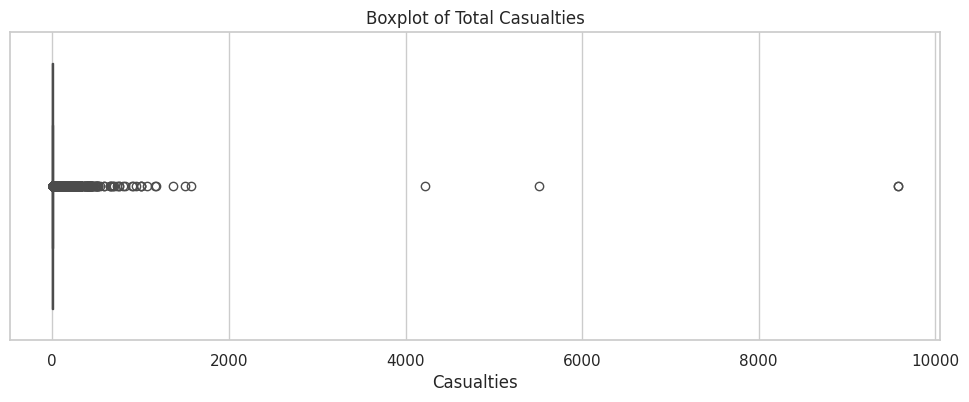

In [ ]:
# 7. OUTLIER ANALYSIS (CASUALTIES)
# Plot boxplot to inspect extreme values in casualties
plt.figure(figsize=(12, 4))
sns.boxplot(x=terror_df['casualties'])
plt.title('Boxplot of Total Casualties')
plt.xlabel('Casualties')
plt.show()

Outlier Interpretation
Extreme casualty values are visible. However, in a terrorism dataset, these are often historically significant high-impact incidents rather than data errors. Therefore, these outliers are retained instead of removed, because removing them would hide important real-world events and distort the severity analysis.

In [ ]:
def safe_barplot(series_data, title, xlabel, ylabel, figsize=(12, 6), horizontal=True):
    """
    Safely plots a bar chart from a Pandas Series.
    If the series is empty, prints a warning instead of raising an error.
    """
    try:
        if series_data.empty:
            print(f"Skipping plot: '{title}' because the data is empty.")
            return

        plt.figure(figsize=figsize)

        if horizontal:
            sns.barplot(x=series_data.values, y=series_data.index)
        else:
            sns.barplot(x=series_data.index, y=series_data.values)
            plt.xticks(rotation=45)

        plt.title(title)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.show()

    except Exception as e:
        print(f"Error while plotting '{title}': {e}")


def safe_countplot(data, x_col, title, xlabel, ylabel, figsize=(12, 6), order=None, rotate_xticks=False):
    """
    Safely plots a countplot for a categorical column.
    """
    try:
        if x_col not in data.columns:
            print(f"Skipping plot: Column '{x_col}' not found.")
            return

        plt.figure(figsize=figsize)
        sns.countplot(data=data, x=x_col, order=order)
        plt.title(title)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        if rotate_xticks:
            plt.xticks(rotation=45)
        plt.show()

    except Exception as e:
        print(f"Error while plotting '{title}': {e}")


def safe_boxplot(data, x=None, y=None, title='', xlabel='', ylabel='', figsize=(12, 6)):
    """
    Safely plots a boxplot.
    """
    try:
        plt.figure(figsize=figsize)
        sns.boxplot(data=data, x=x, y=y)
        plt.title(title)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.show()
    except Exception as e:
        print(f"Error while plotting boxplot '{title}': {e}")


def safe_heatmap(corr_df, title='Correlation Heatmap', figsize=(8, 6)):
    """
    Safely plots a heatmap for a correlation matrix.
    """
    try:
        plt.figure(figsize=figsize)
        sns.heatmap(corr_df, annot=True, cmap='coolwarm', fmt='.2f')
        plt.title(title)
        plt.show()
    except Exception as e:
        print(f"Error while plotting heatmap '{title}': {e}")

def safe_histplot(data, col, title, xlabel, ylabel, figsize=(12, 6), bins=30, xlim=None):
    """
    Safely plots a histogram.
    """
    try:
        if col not in data.columns:
            print(f"Skipping plot: Column '{col}' not found.")
            return

        plt.figure(figsize=figsize)
        sns.histplot(data=data, x=col, bins=bins, kde=True)
        if xlim:
            plt.xlim(xlim)
        plt.title(title)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.show()
    except Exception as e:
        print(f"Error while plotting histogram '{title}': {e}")

UBM-Based Visualization Strategy
This project follows the UBM Rule:

U – Univariate Analysis
Study of one variable at a time to understand its distribution, frequency, or spread.

B – Bivariate Analysis
Study of the relationship between two variables:

Numerical vs Categorical
Numerical vs Numerical
Categorical vs Categorical
M – Multivariate Analysis
Study of interactions among three or more variables to uncover deeper patterns.

U1. Attacks Per Year (Line Chart)

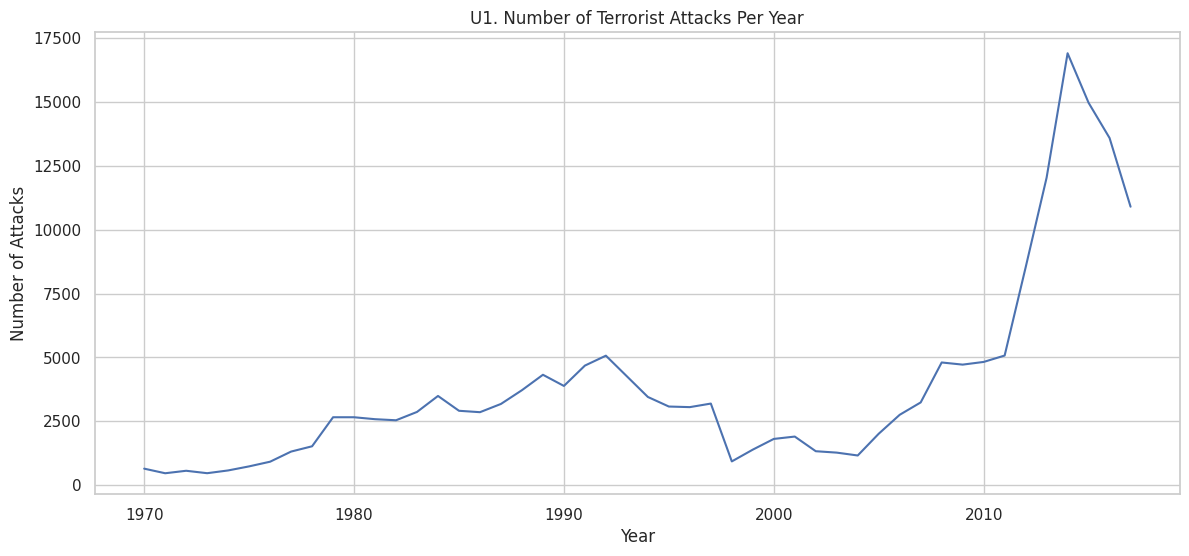

In [ ]:
# U1. NUMBER OF ATTACKS PER YEAR


year_counts = terror_df['iyear'].value_counts().sort_index()

plt.figure(figsize=(14, 6))
year_counts.plot(kind='line')
plt.title('U1. Number of Terrorist Attacks Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.show()


Why did I pick this chart?
A line chart is ideal for time-series analysis because it clearly shows trends, spikes, and declines across years.

Insight(s) found
Terrorist incidents vary significantly over time.
Certain years show sharp surges, indicating periods of intense global instability.
The chart helps identify peak activity periods and long-term historical patterns.
Business Impact / Negative Growth
Yes, this insight creates a positive strategic impact for stakeholders:

Governments can identify historically volatile periods and compare them with geopolitical events.
Security agencies can use this pattern for risk forecasting and preparedness.
A sharp rise in incidents indicates negative global security growth, which may affect tourism, investment, and public safety.
U2. Top 10 Countries by Attack Count (Bar Chart)

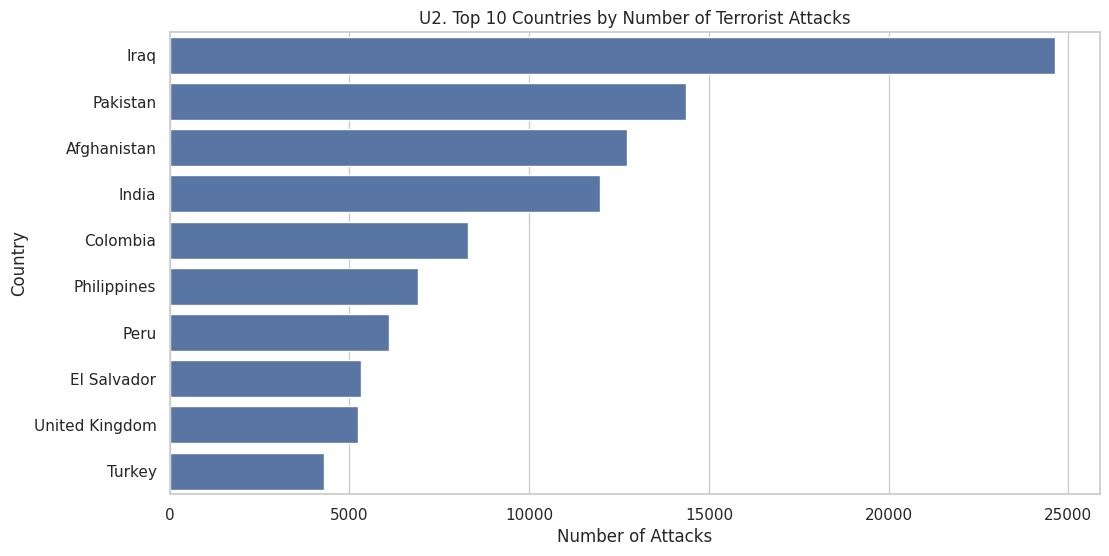

In [ ]:
# U2. TOP 10 COUNTRIES BY NUMBER OF ATTACKS

top_10_countries = terror_df['country_txt'].value_counts().head(10)
safe_barplot(
    series_data=top_10_countries,
    title='U2. Top 10 Countries by Number of Terrorist Attacks',
    xlabel='Number of Attacks',
    ylabel='Country'
)


Why did I pick this chart?
A horizontal bar chart is effective for ranking categories with long names and clearly comparing top countries.

Insight(s) found
A small number of countries account for a large proportion of total attacks.
Terrorism is highly concentrated geographically rather than evenly distributed worldwide.
Business Impact / Negative Growth
Yes, this insight has strong positive decision-making value:

Helps governments and international agencies prioritize security budgets and counter-terrorism operations.
Identifies countries that may need stronger intelligence, policing, or humanitarian support.
High concentration in specific countries indicates negative growth in regional stability and can affect investment, tourism, and citizen confidence.
U3. Region-wise Attack Distribution (Bar Chart)

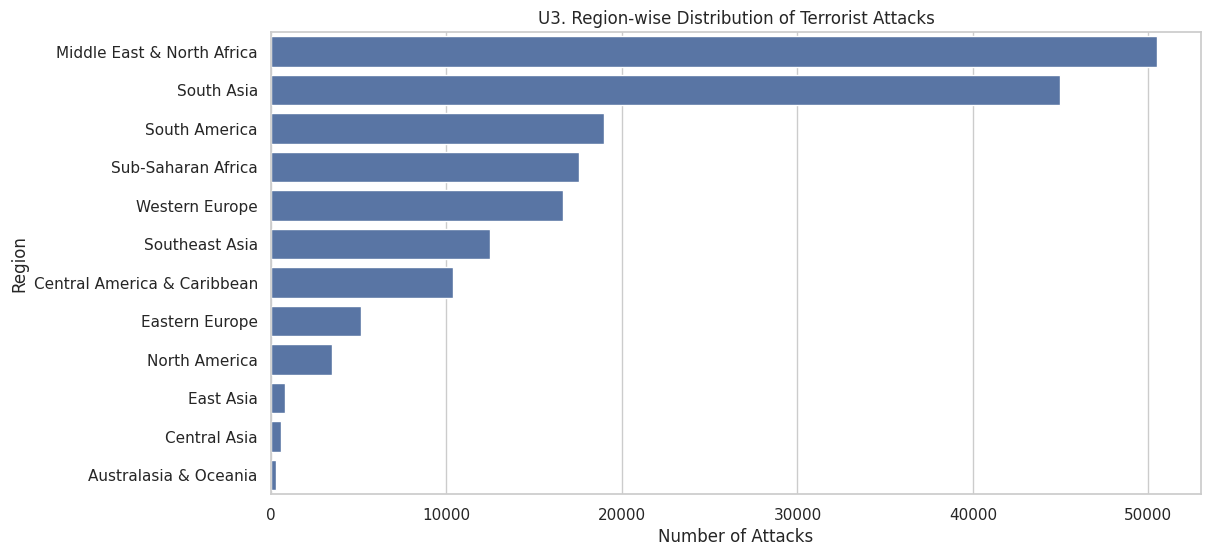

In [ ]:
# U3. REGION-WISE DISTRIBUTION OF ATTACKS

region_counts = terror_df['region_txt'].value_counts()
safe_barplot(
    series_data=region_counts,
    title='U3. Region-wise Distribution of Terrorist Attacks',
    xlabel='Number of Attacks',
    ylabel='Region'
)

Why did I pick this chart?
A bar chart is suitable for comparing frequencies across discrete regions and identifying the most affected zones.

Insight(s) found
Some regions experience significantly more attacks than others.
This suggests the presence of long-term geopolitical hotspots.
Business Impact / Negative Growth
Yes:

Supports regional policy planning, defense strategy, and international cooperation.
Helps humanitarian agencies pre-position resources in high-risk regions.
Regions with very high counts indicate negative growth in security and stability, increasing operational risk for businesses and citizens.
U4. Top 10 Attack Types (Bar Chart)

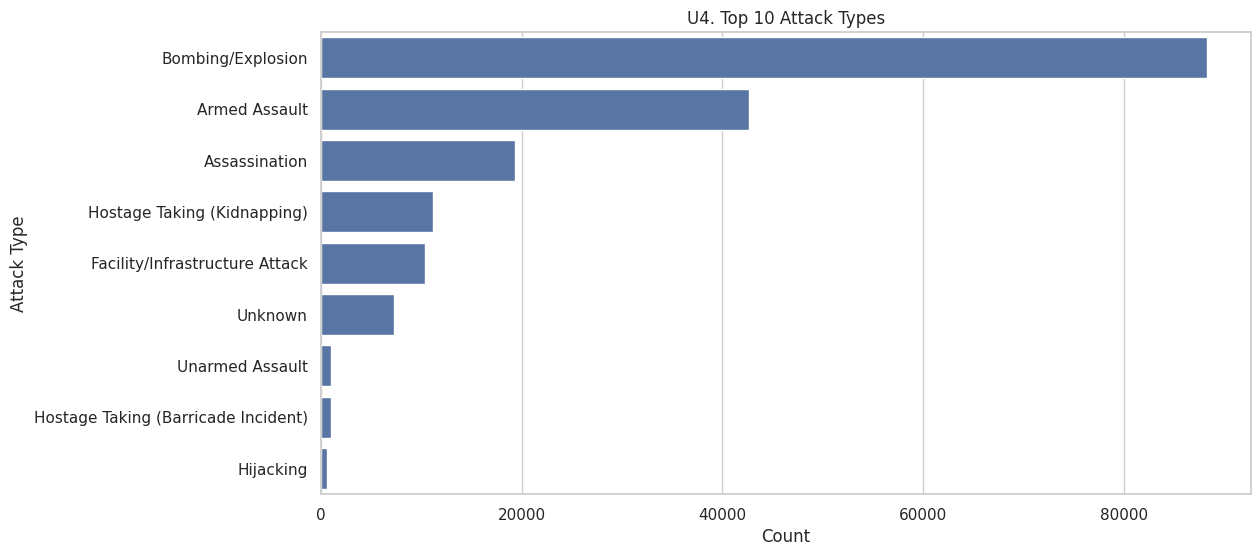

In [ ]:
# U4. TOP 10 ATTACK TYPES

top_attack_types = terror_df['attacktype1_txt'].value_counts().head(10)
safe_barplot(
    series_data=top_attack_types,
    title='U4. Top 10 Attack Types',
    xlabel='Count',
    ylabel='Attack Type'
)

Why did I pick this chart?
A bar chart clearly compares the frequency of attack categories and highlights dominant attack methods.

Insight(s) found
Certain attack methods (such as bombings/explosions or armed assaults) dominate the dataset.
Terrorist tactics are not random; they follow repeated operational patterns.
Business Impact / Negative Growth
Yes:

Security agencies can prioritize preventive measures against the most common attack modes.
Public infrastructure protection can be strengthened based on dominant attack methods.
If bombings dominate, it indicates negative growth in public-space safety and greater need for surveillance and explosive detection systems.
U5. Top 10 Weapon Types (Bar Chart)

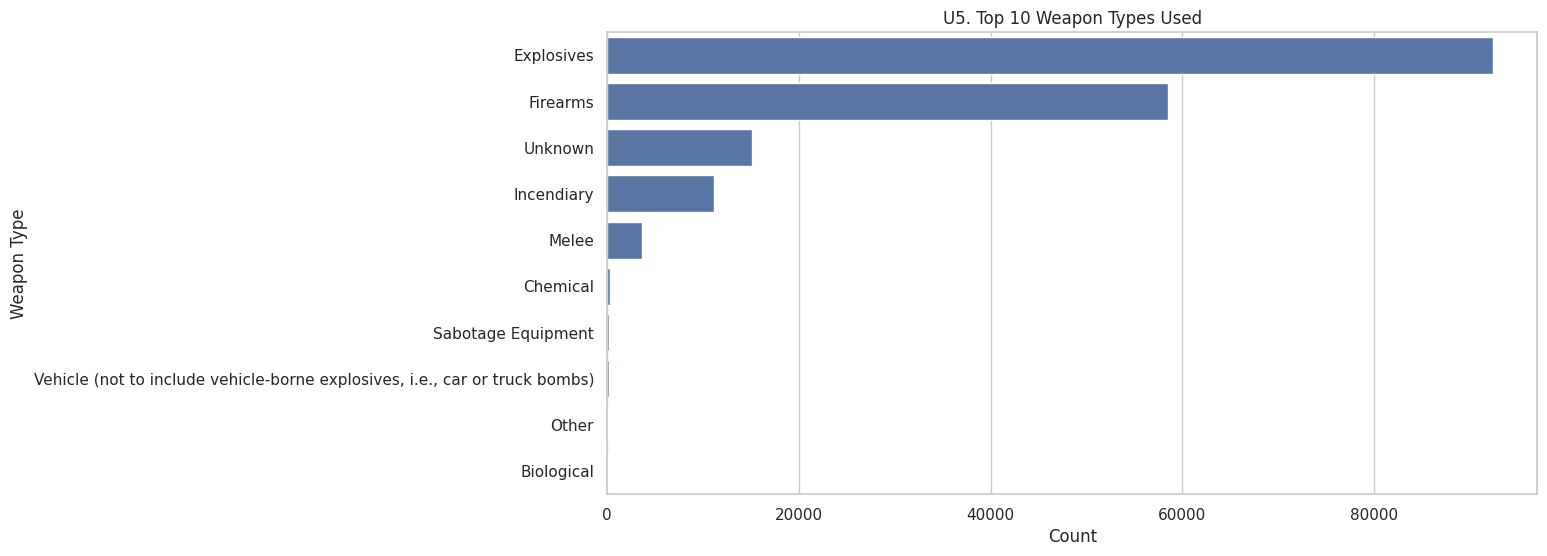

In [ ]:
# U5. TOP 10 WEAPON TYPES USED

top_weapon_types = terror_df['weaptype1_txt'].value_counts().head(10)
safe_barplot(
    series_data=top_weapon_types,
    title='U5. Top 10 Weapon Types Used',
    xlabel='Count',
    ylabel='Weapon Type'
)

Why did I pick this chart?
A bar chart is best for comparing the usage frequency of weapon categories.

Insight(s) found
Explosives and firearms are often among the most frequently used weapons.
Weapon usage trends reveal tactical preferences and operational capabilities.
Business Impact / Negative Growth
Yes:

Helps security and law enforcement focus on weapon detection, border checks, and supply chain monitoring.
Airports, transport hubs, and public places can improve screening for dominant weapon types.
High explosive usage reflects negative growth in public safety, especially in crowded civilian areas.
U6. Top 10 Target Types (Bar Chart)

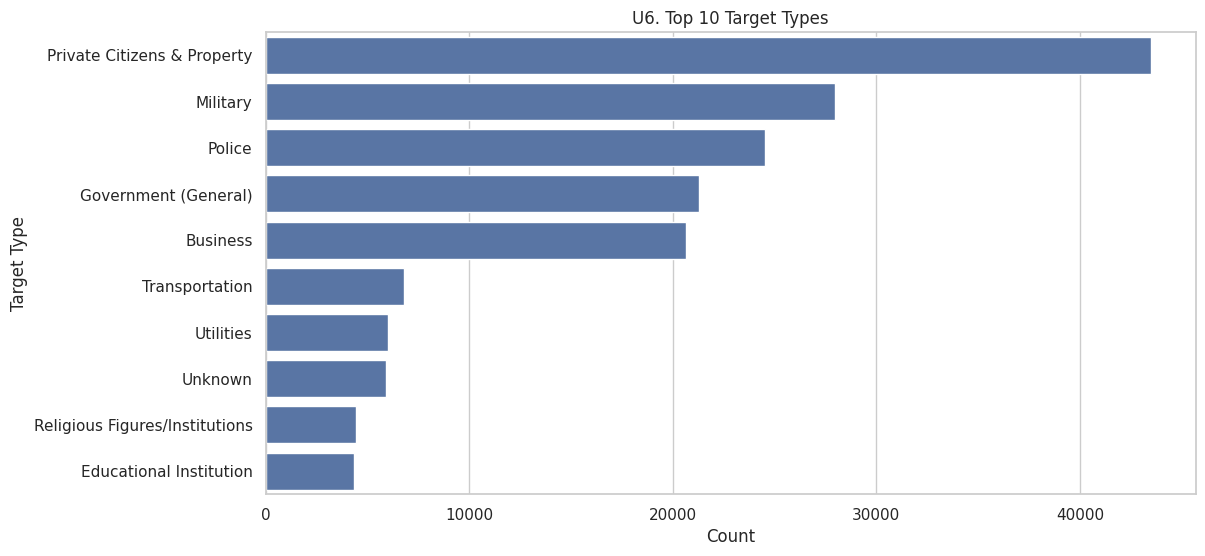

In [ ]:
# U6. TOP 10 TARGET TYPES


top_target_types = terror_df['targtype1_txt'].value_counts().head(10)
safe_barplot(
    series_data=top_target_types,
    title='U6. Top 10 Target Types',
    xlabel='Count',
    ylabel='Target Type'
)

Why did I pick this chart?
A bar chart helps rank target categories and identify which groups or institutions are most frequently attacked.

Insight(s) found
Some target categories (e.g., private citizens, police, military, government) are attacked more often.
This reveals who is most exposed and vulnerable.
Business Impact / Negative Growth
Yes:

Helps governments strengthen protection around the most frequently targeted institutions.
Private-sector organizations can improve risk management and contingency planning.
High attacks on civilians or critical institutions signal negative social and economic stability.
U7. Success vs Failure of Attacks (Count Plot)


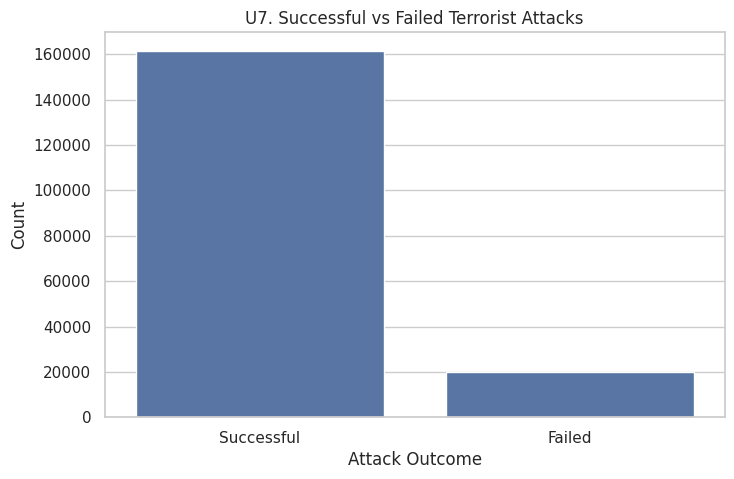

In [ ]:
# U7. SUCCESSFUL VS FAILED ATTACKS

safe_countplot(
    data=terror_df,
    x_col='success_label',
    title='U7. Successful vs Failed Terrorist Attacks',
    xlabel='Attack Outcome',
    ylabel='Count',
    figsize=(8, 5)
)

Why did I pick this chart?
A count plot is the most direct way to compare the frequency of two categorical outcomes: successful vs failed attacks.

Insight(s) found
A large share of incidents are often recorded as successful.
This indicates that many attacks reached at least partial execution.
Business Impact / Negative Growth
Yes:

This is highly important for intelligence and prevention strategy.
A high success ratio indicates negative growth in preventive security systems.
It suggests a need for better surveillance, faster response, and stronger threat interception mechanisms.

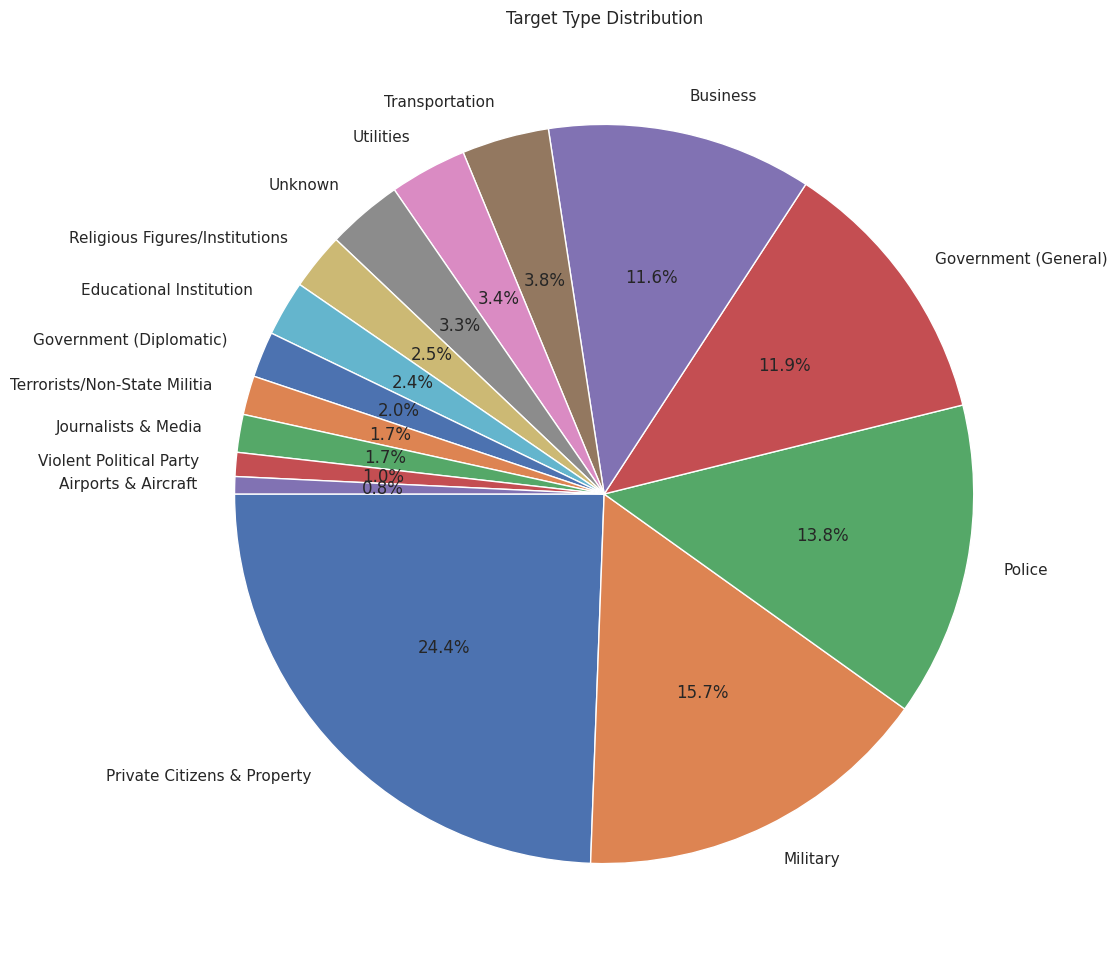

In [ ]:
target_types = df['targtype1_txt'].value_counts().head(15)
plt.figure(figsize=(20,12))
plt.pie(target_types.values, labels=target_types.index, autopct='%1.1f%%', startangle=180)
plt.title('Target Type Distribution')
plt.show()


Why did you pick the specific chart?

I chose a pie chart to visualize the 'Distribution of Target Types in Terrorist Attacks' because it is highly effective for displaying the percentage count of distinct categorical variables. Each sector clearly represents a different target type, and its height immediately conveys the number of times that target type has been attacked. This allows for easy comparison of the prevalence of various targets, making it simple to identify which categories are most frequently targeted by terrorist activities.

What is/are the insight(s) found from the chart?

i. Private Citizens & Property are the most frequent targets: This category accounts for the largest share of terrorist attacks, indicating a primary aim to inflict fear, casualties, and economic disruption among the general populace.

ii. Military and Police are significant targets: Following private citizens, armed forces and law enforcement agencies are the next most commonly targeted entities, suggesting direct confrontations with state authority and security apparatus.

iii. Government (General) and Business sectors are also heavily targeted: This indicates an intent to disrupt governance, economic stability, and public services.

iv. Critical infrastructure and public services like Transportation and Utilities are targeted: This highlights a strategy to create widespread disruption and inconvenience.

v. Educational Institutions and Religious Figures/Institutions are moderately targeted: This points to attacks aimed at undermining social cohesion, ideology, or specific community groups.

vi. Least targeted categories include Diplomatic entities, Terrorists/Non-State Actors, and NGOs: While still occurring, these categories are less frequently targeted compared to the broader civilian and state-related targets.

Will the gained insights help creating a positive business impact?Are there any insights that lead to negative growth? Justify with specific reason.

Yes, understanding the distribution of target types in terrorist attacks can significantly help in creating positive business impacts through informed mitigation strategies, but it also clearly highlights patterns that lead to substantial negative growth.

B — BIVARIATE ANALYSIS (8 CHARTS)

B1. Top 10 Countries by Total Casualties (Bar Chart)




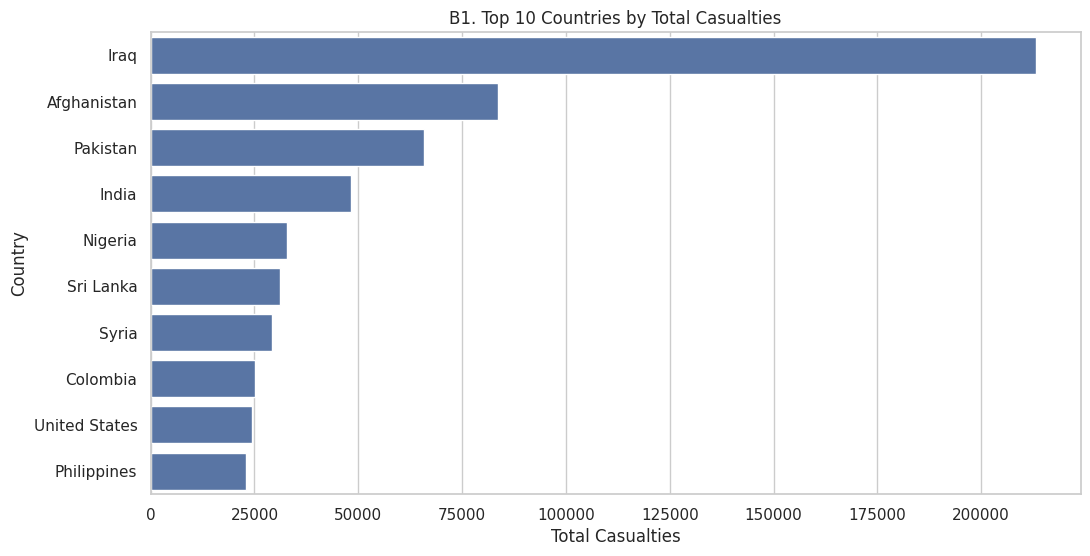

In [ ]:
# B1. TOP 10 COUNTRIES BY TOTAL CASUALTIES


country_casualties = terror_df.groupby('country_txt')['casualties'].sum().sort_values(ascending=False).head(10)

safe_barplot(
    series_data=country_casualties,
    title='B1. Top 10 Countries by Total Casualties',
    xlabel='Total Casualties',
    ylabel='Country'
)

Why did I pick this chart?
A bar chart is ideal for comparing total casualties across countries and highlighting severity, not just frequency.

Insight(s) found
Some countries may not only have many attacks but also much higher human impact.
This separates high-frequency regions from high-severity regions.
Business Impact / Negative Growth
Yes:

Helps prioritize medical preparedness, emergency response, and humanitarian support.
Countries with high casualty totals require stronger crisis management systems.
High casualty concentration reflects negative growth in human security and public resilience.
B2. Average Casualties by Attack Type (Top 10) (Bar Chart)

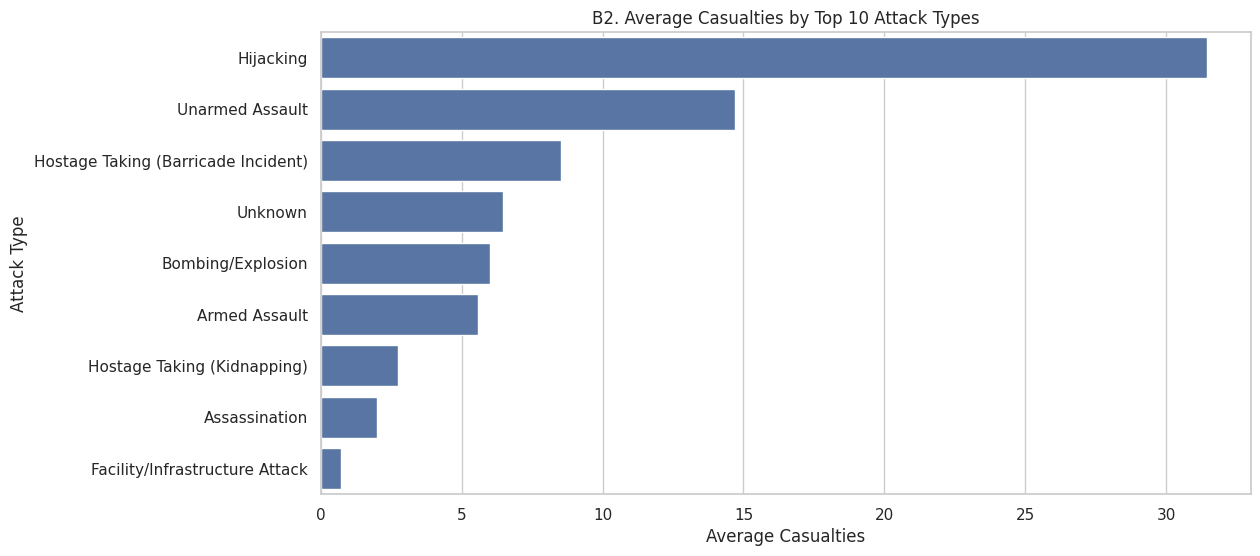

In [ ]:
# B2. AVERAGE CASUALTIES BY ATTACK TYPE (TOP 10 BY FREQUENCY)

# Focus on the top 10 most frequent attack types for stable comparison
top_10_attack_labels = terror_df['attacktype1_txt'].value_counts().head(10).index

avg_casualties_attack = (
    terror_df[terror_df['attacktype1_txt'].isin(top_10_attack_labels)]
    .groupby('attacktype1_txt')['casualties']
    .mean()
    .sort_values(ascending=False)
)

safe_barplot(
    series_data=avg_casualties_attack,
    title='B2. Average Casualties by Top 10 Attack Types',
    xlabel='Average Casualties',
    ylabel='Attack Type'
)

Why did I pick this chart?
A bar chart effectively compares the average human impact of different attack types.

Insight(s) found
Some attack types may be less frequent but far more deadly on average.
This distinguishes common methods from high-severity methods.
Business Impact / Negative Growth
Yes:

Security planning should focus not only on frequent attack types but also on the most lethal ones.
Helps optimize emergency response and preventive investment.
Attack types with high average casualties indicate negative growth in mass-casualty risk.
B3. Average Casualties by Weapon Type (Top 10) (Bar Chart)

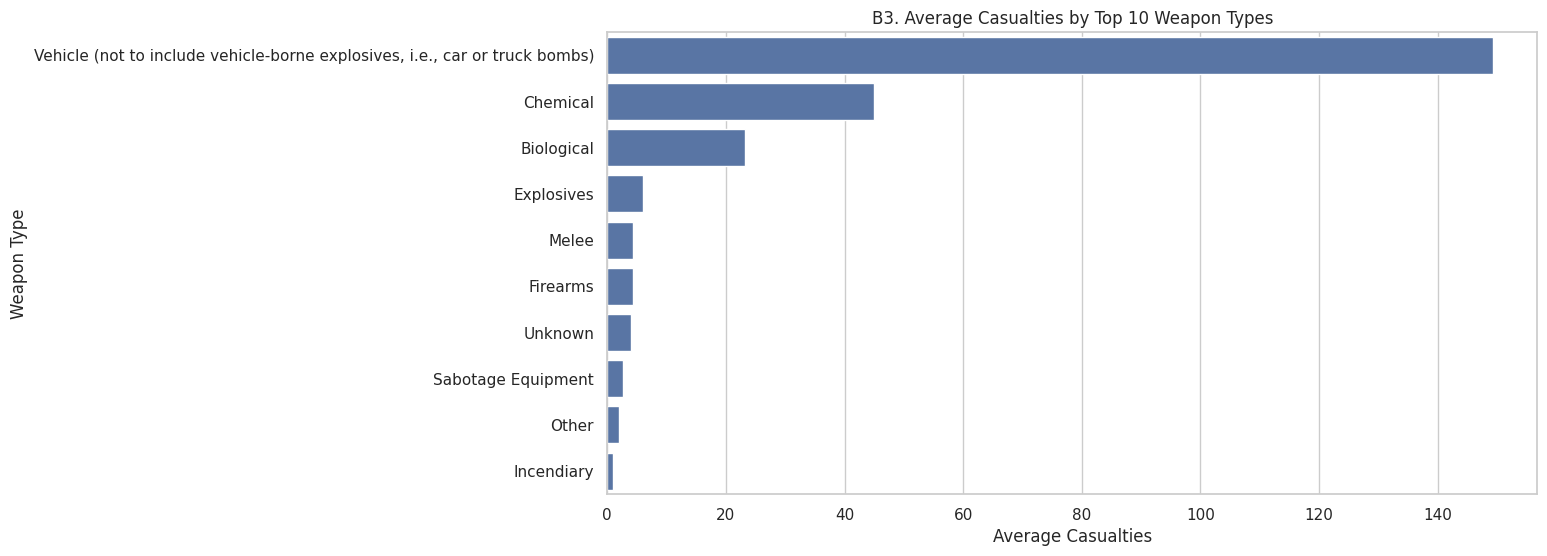

In [ ]:
# B3. AVERAGE CASUALTIES BY WEAPON TYPE (TOP 10 BY FREQUENCY)


top_10_weapon_labels = terror_df['weaptype1_txt'].value_counts().head(10).index

avg_casualties_weapon = (
    terror_df[terror_df['weaptype1_txt'].isin(top_10_weapon_labels)]
    .groupby('weaptype1_txt')['casualties']
    .mean()
    .sort_values(ascending=False)
)

safe_barplot(
    series_data=avg_casualties_weapon,
    title='B3. Average Casualties by Top 10 Weapon Types',
    xlabel='Average Casualties',
    ylabel='Weapon Type'
)

Why did I pick this chart?
A bar chart is suitable for comparing average casualty impact across weapon categories.

Insight(s) found
Certain weapons may be used less often but cause more casualties per incident.
This highlights which weapon types carry the highest average threat.
Business Impact / Negative Growth
Yes:

Helps authorities focus on high-impact weapon detection and control.
Useful for public venue security design and emergency training.
Weapons with higher casualty averages indicate negative growth in incident severity and public vulnerability.
B4. Success Rate by Attack Type (Bar Chart)

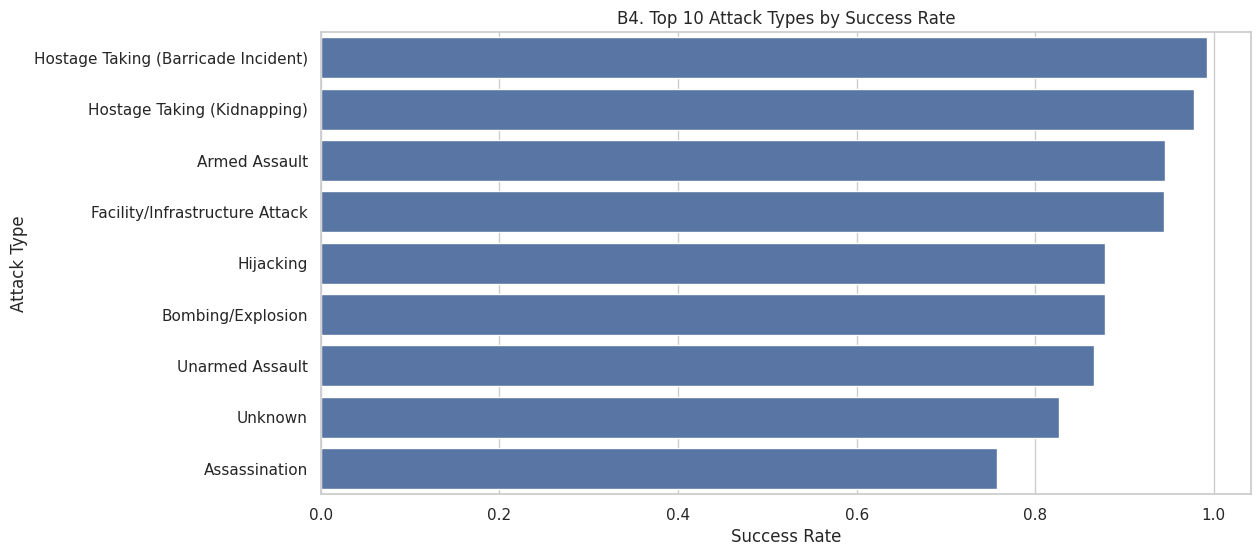

In [ ]:
# B4. SUCCESS RATE BY ATTACK TYPE


# Compute average of binary success column => success rate
success_rate_attack = (
    terror_df.groupby('attacktype1_txt')['success']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

safe_barplot(
    series_data=success_rate_attack,
    title='B4. Top 10 Attack Types by Success Rate',
    xlabel='Success Rate',
    ylabel='Attack Type'
)


Why did I pick this chart?
A bar chart is excellent for comparing success rates across categories.

Insight(s) found
Some attack types are more operationally successful than others.
This may reflect ease of execution, accessibility, or lower detection risk.
Business Impact / Negative Growth
Yes:

Helps prioritize preventive systems against the attack types most likely to succeed.
Supports targeted upgrades in surveillance and law enforcement training.
High success rates indicate negative growth in defensive effectiveness.
B5. Property Damage vs Attack Outcome (Count Plot)

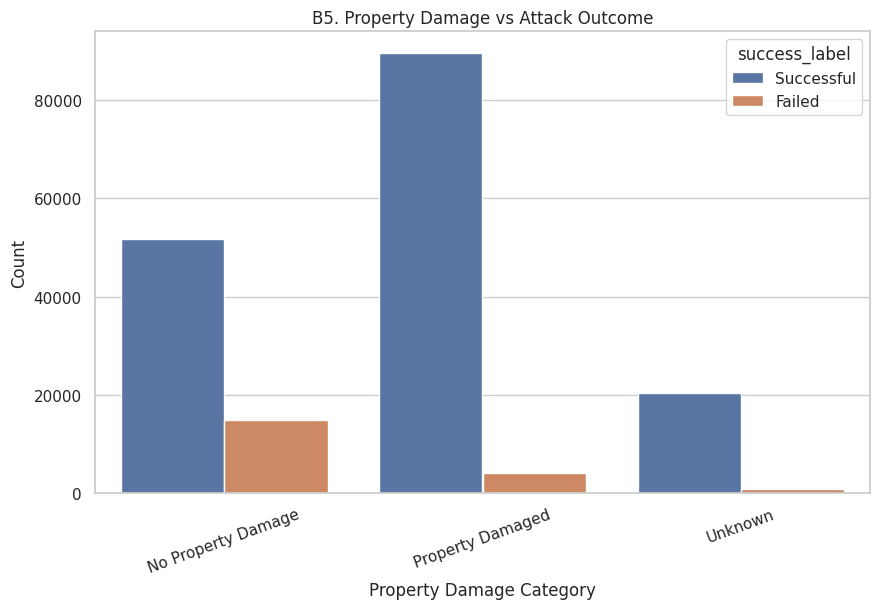

In [ ]:
# B5. PROPERTY DAMAGE VS ATTACK OUTCOME

plt.figure(figsize=(10, 6))
sns.countplot(data=terror_df, x='property_label', hue='success_label')
plt.title('B5. Property Damage vs Attack Outcome')
plt.xlabel('Property Damage Category')
plt.ylabel('Count')
plt.xticks(rotation=20)
plt.show()


Why did I pick this chart?
A count plot with hue is useful for comparing how attack outcomes vary across property damage categories.

Insight(s) found
Successful attacks are more likely to be associated with property damage.
Property damage can serve as an indicator of attack severity and operational impact.
Business Impact / Negative Growth
Yes:

Helps insurers, infrastructure planners, and governments assess asset vulnerability.
Supports protection of critical infrastructure and urban resilience planning.
High property damage linked to successful attacks signals negative economic growth pressure through reconstruction costs and investor uncertainty.
B6. Monthly Distribution of Attacks (Bar Chart)

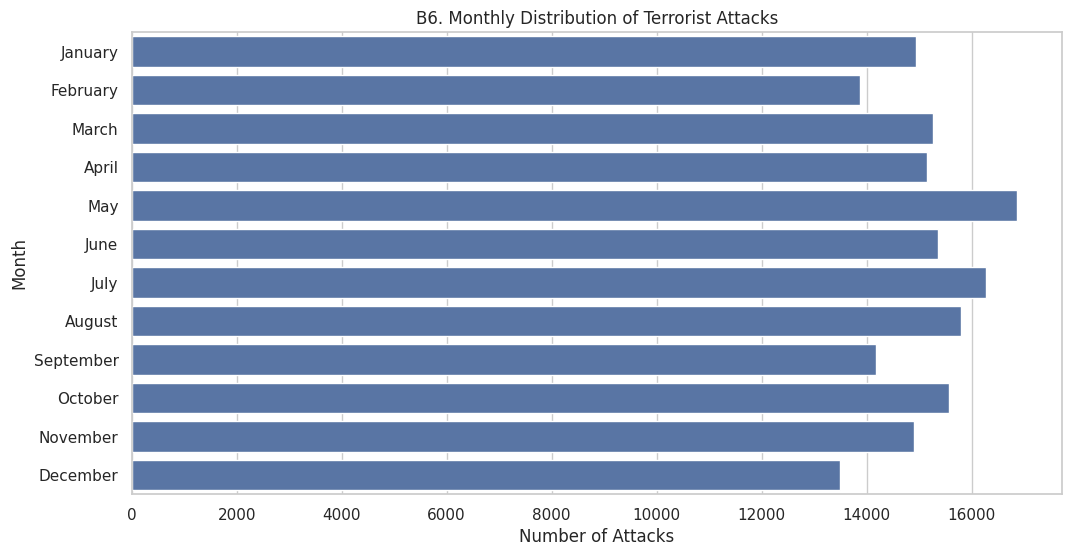

In [ ]:
# B6. MONTHLY DISTRIBUTION OF ATTACKS

# Keep only valid month names
monthly_counts = terror_df['month_name'].value_counts()

# Reorder months chronologically
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

monthly_counts = monthly_counts.reindex(month_order).dropna()

safe_barplot(
    series_data=monthly_counts,
    title='B6. Monthly Distribution of Terrorist Attacks',
    xlabel='Number of Attacks',
    ylabel='Month'
)

Why did I pick this chart?
A bar chart is appropriate for comparing monthly frequencies and identifying seasonal concentration.

Insight(s) found
Some months may show higher attack activity than others.
This may suggest seasonal, political, or event-driven patterns.
Business Impact / Negative Growth
Yes:

Helps security agencies plan seasonal alertness, staffing, and event security.
Useful for protecting festivals, elections, or high-traffic periods.
Seasonal spikes can signal temporary negative growth in public safety and operational risk.
B7. Top 10 Groups by Number of Attacks (Bar Chart)

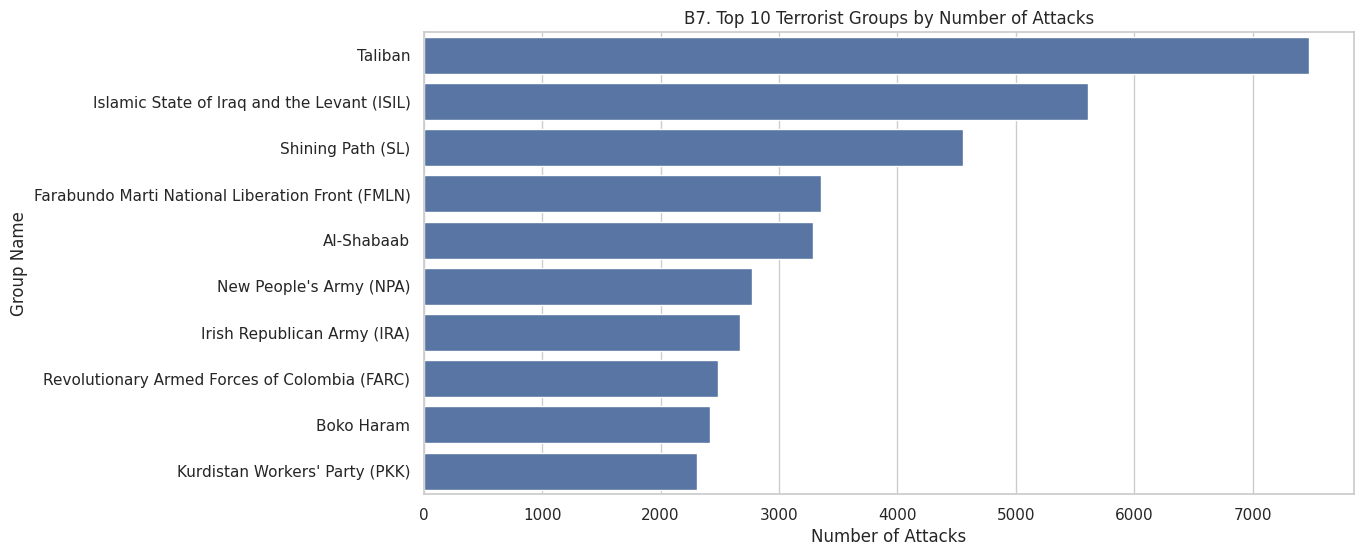

In [ ]:
# B7. TOP 10 TERRORIST GROUPS BY ATTACK COUNT

top_groups = terror_df[terror_df['gname'] != 'Unknown']['gname'].value_counts().head(10)

safe_barplot(
    series_data=top_groups,
    title='B7. Top 10 Terrorist Groups by Number of Attacks',
    xlabel='Number of Attacks',
    ylabel='Group Name'
)

Why did I pick this chart?
A bar chart is ideal for ranking the most active terrorist groups.

Insight(s) found
A relatively small number of groups are responsible for a significant portion of attacks.
Threat activity is concentrated among repeat actors.
Business Impact / Negative Growth
Yes:

Highly valuable for intelligence prioritization and targeted monitoring.
Helps focus counter-terrorism efforts on the most operationally active groups.
Persistent activity by a few groups indicates negative growth in threat containment.
B8. Correlation Between Killed, Wounded, Casualties, Success (Heatmap)

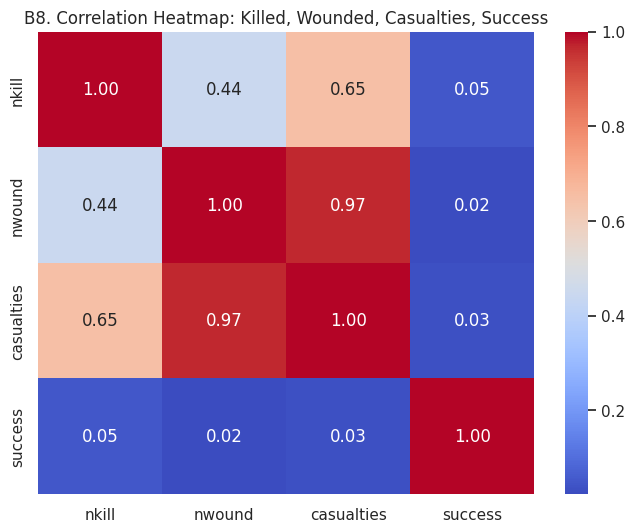

In [ ]:
# B8. CORRELATION HEATMAP (NUMERICAL-NUMERICAL)


corr_cols = ['nkill', 'nwound', 'casualties', 'success']
corr_matrix = terror_df[corr_cols].corr()

safe_heatmap(
    corr_df=corr_matrix,
    title='B8. Correlation Heatmap: Killed, Wounded, Casualties, Success'
)


Why did I pick this chart?
A heatmap is the best way to visualize pairwise correlations among numerical variables in a compact format.

Insight(s) found
casualties strongly correlates with nkill and nwound, as expected.
The relationship between success and casualties may be weaker than expected, showing that success does not always mean high casualties.
Business Impact / Negative Growth
Yes:

Helps analysts understand which metrics move together and which do not.
Useful for designing future risk scoring systems and predictive models.
If successful attacks do not always imply high casualties, stakeholders must avoid oversimplified risk assumptions.
M — MULTIVARIATE ANALYSIS (6 CHARTS)

M1. Top 10 Countries by Attacks, Colored by Average Casualties (Bar Chart)

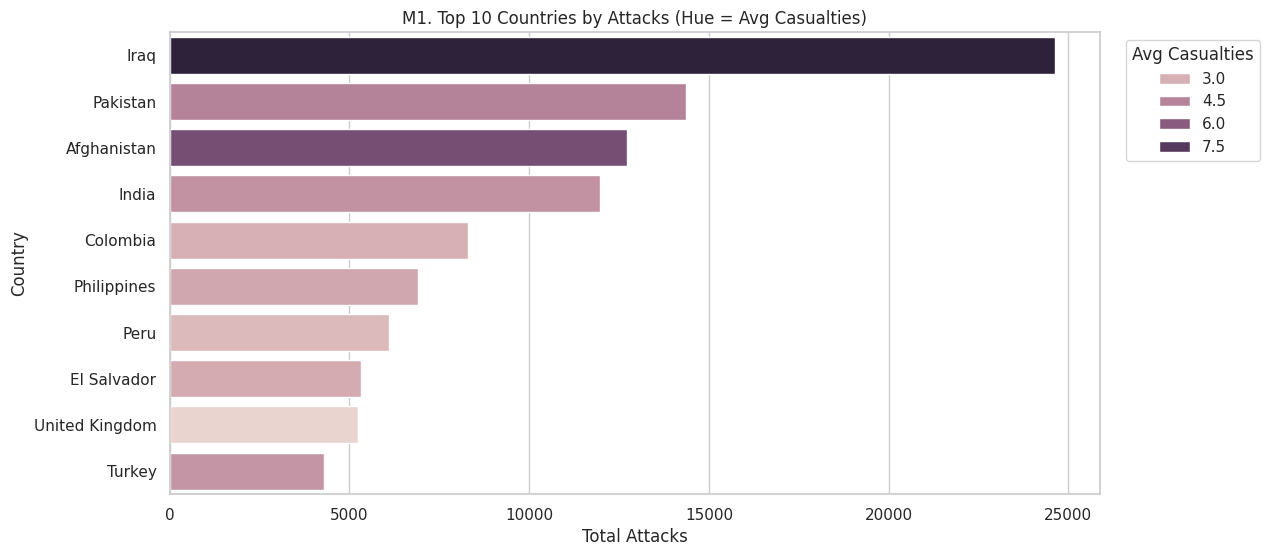

In [ ]:
# M1. TOP 10 COUNTRIES BY ATTACK COUNT + AVG CASUALTIES

country_attack_count = terror_df['country_txt'].value_counts().head(10).index

country_multi = (
    terror_df[terror_df['country_txt'].isin(country_attack_count)]
    .groupby('country_txt')
    .agg(
        total_attacks=('country_txt', 'count'),
        avg_casualties=('casualties', 'mean')
    )
    .sort_values('total_attacks', ascending=False)
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.barplot(data=country_multi, x='total_attacks', y='country_txt', hue='avg_casualties', dodge=False)
plt.title('M1. Top 10 Countries by Attacks (Hue = Avg Casualties)')
plt.xlabel('Total Attacks')
plt.ylabel('Country')
plt.legend(title='Avg Casualties', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

Why did I pick this chart?
This is a multivariate bar chart because it combines:

Country
Total attacks
Average casualties (as hue)
It helps compare both frequency and severity together.

Insight(s) found
Some countries have very high attack counts but moderate average casualties.
Others may have fewer attacks but higher average severity.
Business Impact / Negative Growth
Yes:

This helps distinguish high-frequency risk from high-severity risk.
Governments can prioritize resources differently: prevention for high-frequency areas, trauma response for high-severity areas.
Countries with both high attacks and high casualties reflect serious negative growth in security resilience.
M2. Year vs Casualties Trend (Line Plot of Annual Casualties)

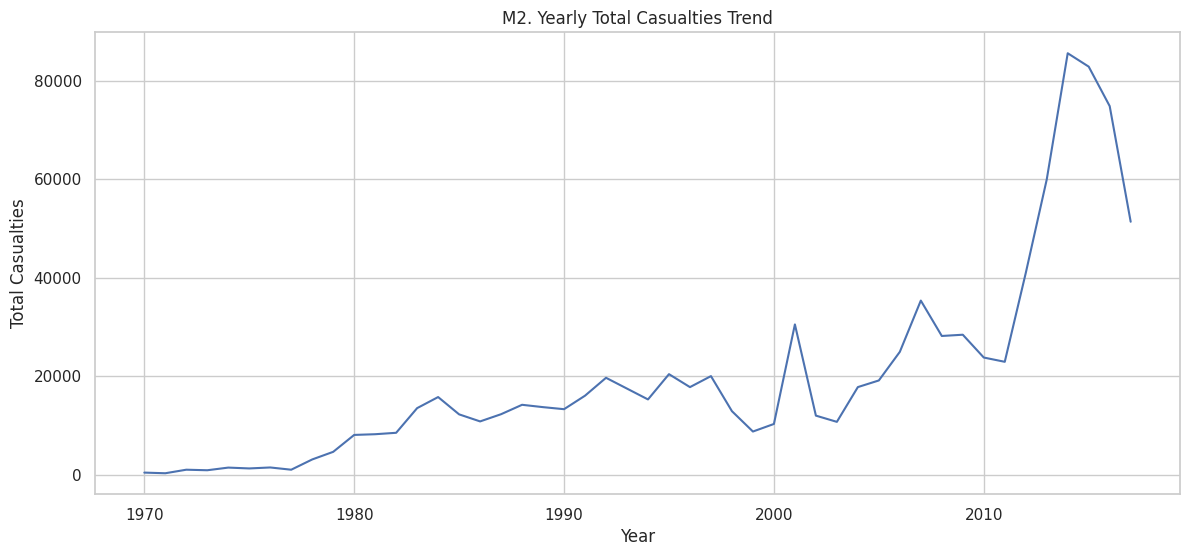

In [ ]:
# M2. YEARLY TOTAL CASUALTIES TREND

yearly_casualties = terror_df.groupby('iyear')['casualties'].sum()

plt.figure(figsize=(14, 6))
yearly_casualties.plot(kind='line')
plt.title('M2. Yearly Total Casualties Trend')
plt.xlabel('Year')
plt.ylabel('Total Casualties')
plt.show()

Why did I pick this chart?
A line chart is ideal for tracking how the total human impact changes over time.

Insight(s) found
Attack frequency and casualty severity do not always rise together.
Some years may have fewer attacks but much higher casualties, indicating more severe incidents.
Business Impact / Negative Growth
Yes:

Helps separate volume risk from severity risk.
Supports better emergency preparedness and hospital readiness.
Years with spikes in casualties indicate negative growth in humanitarian safety, even if attack counts are not at their peak.
M3. Top 10 Countries × Success Rate (Bar Chart)

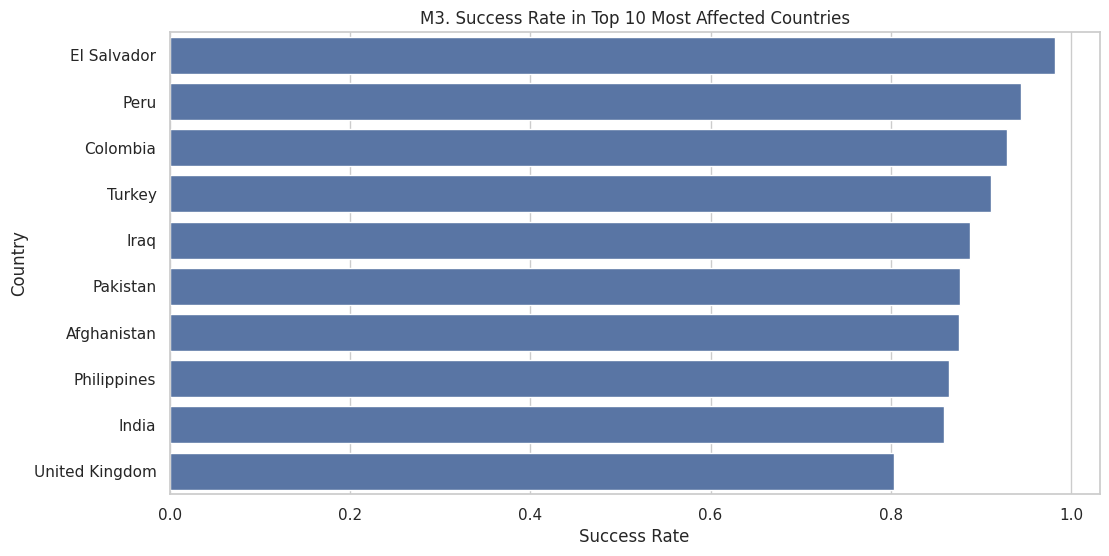

In [ ]:
# M3. SUCCESS RATE IN TOP 10 MOST AFFECTED COUNTRIES

top_10_country_names = terror_df['country_txt'].value_counts().head(10).index

country_success_rate = (
    terror_df[terror_df['country_txt'].isin(top_10_country_names)]
    .groupby('country_txt')['success']
    .mean()
    .sort_values(ascending=False)
)

safe_barplot(
    series_data=country_success_rate,
    title='M3. Success Rate in Top 10 Most Affected Countries',
    xlabel='Success Rate',
    ylabel='Country'
)


Why did I pick this chart?
This chart compares country and success rate, linking geography with operational outcome.

Insight(s) found
Some high-incident countries also show high success rates.
This may indicate stronger attacker adaptation or weaker preventive systems in those locations.
Business Impact / Negative Growth
Yes:

Helps governments identify where attacks are not only frequent but also more likely to succeed.
This is highly actionable for improving intelligence, rapid response, and infrastructure security.
High success rates in high-attack countries indicate negative growth in operational defense effectiveness.
M4. Attack Type × Weapon Type (Top 10 combinations) (Heatmap)

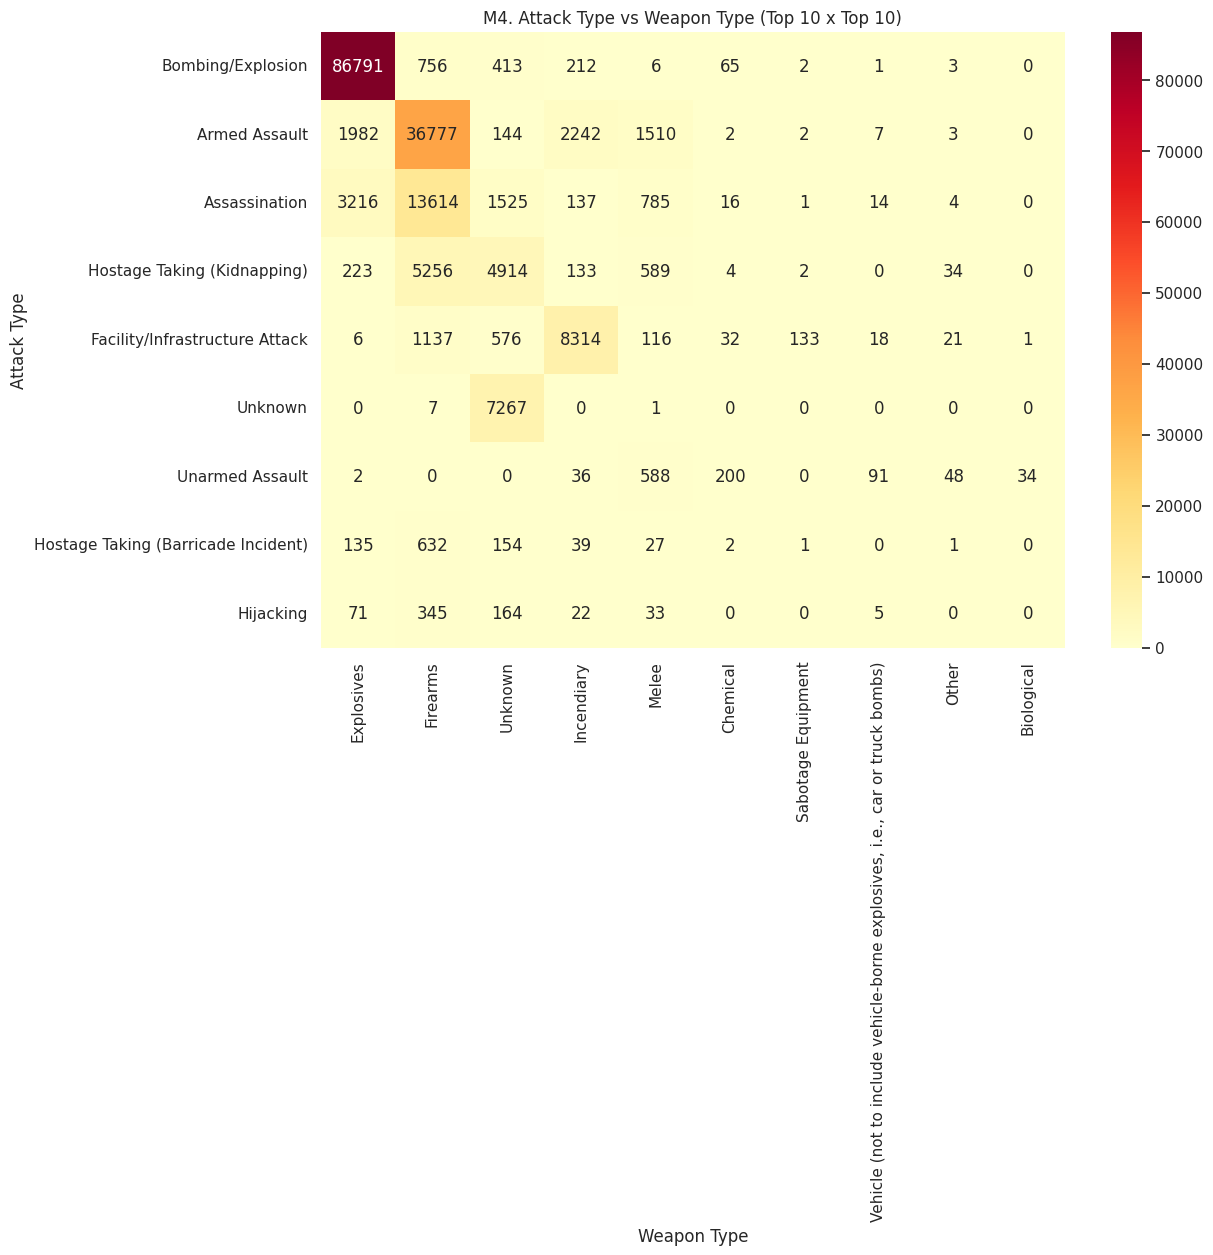

In [ ]:
# M4. ATTACK TYPE VS WEAPON TYPE (TOP COMBINATIONS)

# Create crosstab of attack type and weapon type
attack_weapon_ct = pd.crosstab(terror_df['attacktype1_txt'], terror_df['weaptype1_txt'])

# Reduce to top 10 attack types and top 10 weapon types for readability
top_attack_rows = terror_df['attacktype1_txt'].value_counts().head(10).index
top_weapon_cols = terror_df['weaptype1_txt'].value_counts().head(10).index

attack_weapon_ct_small = attack_weapon_ct.loc[top_attack_rows, top_weapon_cols]

plt.figure(figsize=(12, 8))
sns.heatmap(attack_weapon_ct_small, annot=True, fmt='d', cmap='YlOrRd')
plt.title('M4. Attack Type vs Weapon Type (Top 10 x Top 10)')
plt.xlabel('Weapon Type')
plt.ylabel('Attack Type')
plt.show()

Why did I pick this chart?
A heatmap is ideal for visualizing interaction intensity between two categorical variables.

Insight(s) found
Certain attack types are strongly associated with specific weapon types.
This reveals tactical pairings such as bombings with explosives or assaults with firearms.
Business Impact / Negative Growth
Yes:

Extremely useful for threat pattern recognition and targeted preventive measures.
Helps transportation hubs, public venues, and law enforcement plan screening based on likely combinations.
Strong recurring tactical combinations indicate negative growth in attack pattern predictability being exploited by adversaries.
M5. Region × Average Casualties × Success Rate (Bar Chart with Hue)

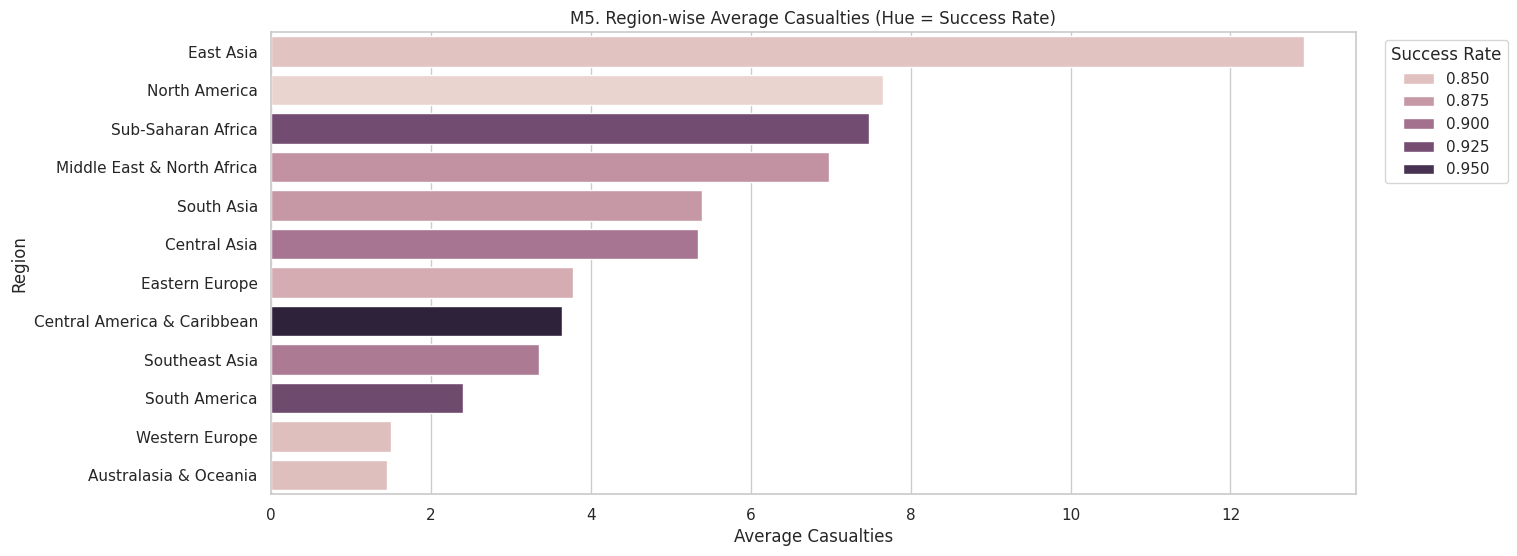

In [ ]:
# M5. REGION-WISE AVG CASUALTIES WITH SUCCESS RATE

region_multi = (
    terror_df.groupby('region_txt')
    .agg(
        avg_casualties=('casualties', 'mean'),
        success_rate=('success', 'mean')
    )
    .sort_values('avg_casualties', ascending=False)
    .reset_index()
)

plt.figure(figsize=(14, 6))
sns.barplot(data=region_multi, x='avg_casualties', y='region_txt', hue='success_rate', dodge=False)
plt.title('M5. Region-wise Average Casualties (Hue = Success Rate)')
plt.xlabel('Average Casualties')
plt.ylabel('Region')
plt.legend(title='Success Rate', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

Why did I pick this chart?
This is a multivariate chart because it compares:

Region
Average casualties
Success rate
It combines severity and operational efficiency at the regional level.

Insight(s) found
Some regions may have moderate attack frequency but very high average casualties.
Some regions may show both high average casualties and high success rates, indicating particularly dangerous operational environments.
Business Impact / Negative Growth
Yes:

Helps international agencies prioritize the most dangerous regions, not just the most active ones.
Useful for emergency preparedness, medical planning, and geopolitical risk analysis.
Regions with high severity and high success rates reflect negative growth in regional security stability

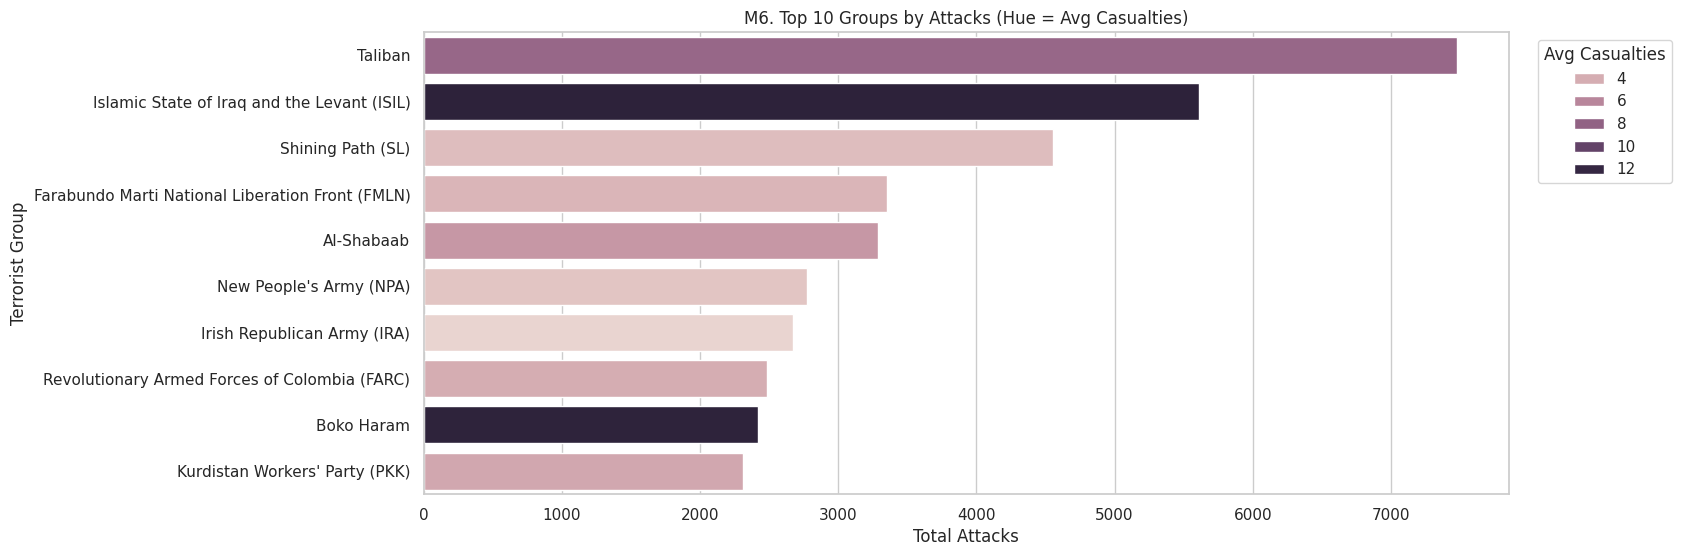

In [ ]:
# M6. TOP 10 GROUPS BY ATTACKS + AVG CASUALTIES


top_10_group_names = terror_df[terror_df['gname'] != 'Unknown']['gname'].value_counts().head(10).index

group_multi = (
    terror_df[terror_df['gname'].isin(top_10_group_names)]
    .groupby('gname')
    .agg(
        total_attacks=('gname', 'count'),
        avg_casualties=('casualties', 'mean')
    )
    .sort_values('total_attacks', ascending=False)
    .reset_index()
)

plt.figure(figsize=(14, 6))
sns.barplot(data=group_multi, x='total_attacks', y='gname', hue='avg_casualties', dodge=False)
plt.title('M6. Top 10 Groups by Attacks (Hue = Avg Casualties)')
plt.xlabel('Total Attacks')
plt.ylabel('Terrorist Group')
plt.legend(title='Avg Casualties', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

Why did I pick this chart?
This chart is multivariate because it combines:

Group name
Number of attacks
Average casualties
It helps compare activity level and deadliness together.

Insight(s) found
Some groups are highly active but less deadly per attack.
Others may be less frequent but more severe on average.
Business Impact / Negative Growth
Yes:

Helps intelligence agencies prioritize not just the most active groups, but the most dangerous ones.
Supports more nuanced threat ranking and targeted counter-measures.Groups with both high activity and high casualties represent serious negative growth in national and international security.


Top 10 Cities by Attacks

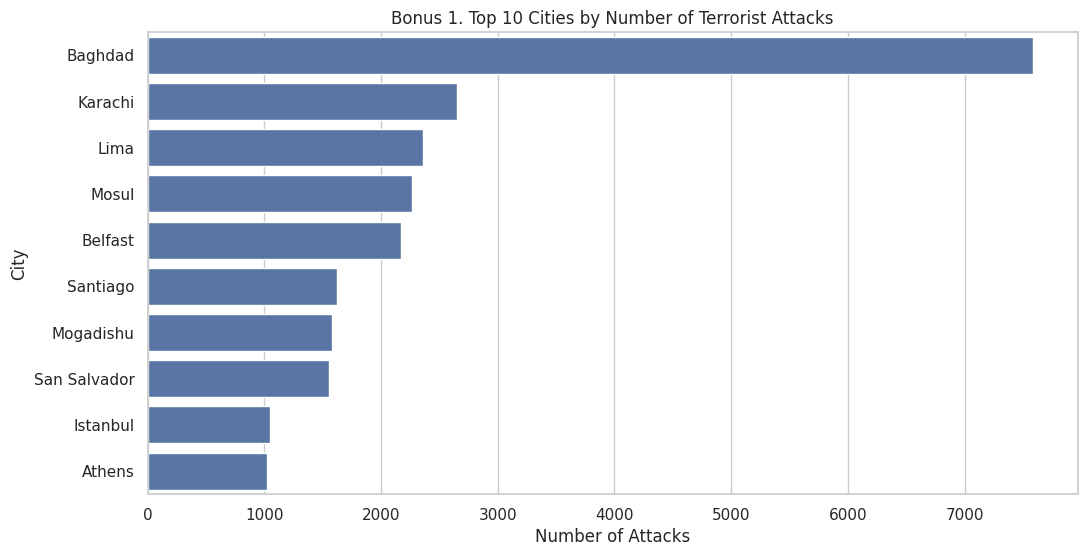

In [ ]:
#  TOP 10 CITIES BY ATTACKS

top_cities = terror_df[terror_df['city'] != 'Unknown']['city'].value_counts().head(10)

safe_barplot(
    series_data=top_cities,
    title='Bonus 1. Top 10 Cities by Number of Terrorist Attacks',
    xlabel='Number of Attacks',
    ylabel='City'
)


Distribution of Casualties (0–100 range)

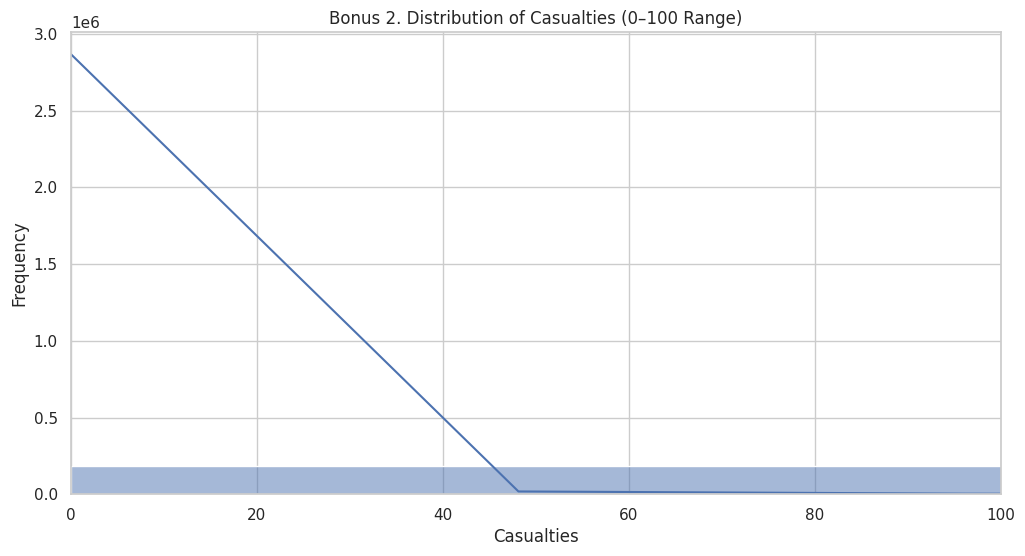

In [ ]:
# DISTRIBUTION OF CASUALTIES (FOCUSED RANGE)

safe_histplot(
    data=terror_df,
    col='casualties',
    title='Bonus 2. Distribution of Casualties (0–100 Range)',
    xlabel='Casualties',
    ylabel='Frequency',
    bins=50,
    xlim=(0, 100)
)

1 Which year had the highest number of attacks?

In [ ]:
year_attacks = terror_df['iyear'].value_counts().sort_index()
peak_year = year_attacks.idxmax()
peak_attacks = year_attacks.max()

print("Year with highest number of attacks:", peak_year)
print("Number of attacks:", peak_attacks)

Year with highest number of attacks: 2014
Number of attacks: 16903


2 Which country had the highest number of attacks?

In [ ]:
top_country = terror_df['country_txt'].value_counts().head(1)
print("Country with highest attacks:\n")
print(top_country)


Country with highest attacks:

country_txt
Iraq    24636
Name: count, dtype: int64


3 Which region is most affected?

In [ ]:
top_region = terror_df['region_txt'].value_counts().head(1)
print("Most affected region:\n")
print(top_region)


Most affected region:

region_txt
Middle East & North Africa    50474
Name: count, dtype: int64


4. Most common attack type

In [ ]:
top_attack_type = terror_df['attacktype1_txt'].value_counts().head(1)
print("Most common attack type:\n")
print(top_attack_type)

Most common attack type:

attacktype1_txt
Bombing/Explosion    88255
Name: count, dtype: int64


5.Most commonly used weapon type

In [ ]:
top_weapon = terror_df['weaptype1_txt'].value_counts().head(1)
print("Most commonly used weapon type:\n")
print(top_weapon)

Most commonly used weapon type:

weaptype1_txt
Explosives    92426
Name: count, dtype: int64


6.Terrorist group with highest attacks

In [ ]:
top_group = terror_df[terror_df['gname'] != 'Unknown']['gname'].value_counts().head(1)
print("Terrorist group with highest attacks:\n")
print(top_group)

Terrorist group with highest attacks:

gname
Taliban    7478
Name: count, dtype: int64


7.Top 10 countries by total casualties

In [ ]:
country_casualties = terror_df.groupby('country_txt')['casualties'].sum().sort_values(ascending=False)
print("Top 10 countries by casualties:\n")
print(country_casualties.head(10))


Top 10 countries by casualties:

country_txt
Iraq             213279.0
Afghanistan       83661.0
Pakistan          65860.0
India             48321.0
Nigeria           32921.0
Sri Lanka         31091.0
Syria             29338.0
Colombia          25026.0
United States     24473.0
Philippines       22926.0
Name: casualties, dtype: float64


5. Solution to Business Objective
What do you suggest the client to achieve Business Objective ?

Recommendations
Increase surveillance and intelligence sharing in high-risk countries and regions.
Focus preventive strategies on the most common attack types such as bombings and armed assaults.
Improve emergency medical response systems in regions with high casualty counts.
Monitor highly active terrorist groups more closely.
Use historical terrorism data to build predictive warning systems in future work.
Conclusion
This project analyzed the Global Terrorism Dataset (1970–2017) to uncover important patterns and trends in terrorist activities worldwide. By performing data cleaning, handling missing values, exploring the data, and creating visualizations, the analysis identified the most affected countries and regions, common attack types, weapon usage patterns, major terrorist groups, and casualty distributions. The findings of this project are valuable for governments, security agencies, policy makers, researchers, and humanitarian organizations to improve preventive strategies, strengthen public safety measures, and allocate resources more effectively.



Stakeholder Usefulness
1. Governments and Policy Makers
Helps identify terrorism hotspots.
Supports better allocation of security budgets and resources.
Assists in creating region-specific counter-terrorism policies.
2. Security and Intelligence Agencies
Helps understand attack patterns, weapon usage, and active groups.
Supports surveillance planning and preventive actions.
3. Researchers and Analysts
Useful for studying long-term global terrorism trends.
Helps in building predictive and risk-analysis models in future.
4. Humanitarian and Emergency Services
Helps prepare medical and disaster response systems in high-risk areas.
Supports better emergency planning and rescue management.
5. International Organizations (UN, NGOs)
Assists in global peacekeeping and international security collaboration.
Supports planning for humanitarian aid in conflict-prone regions.

Key Insights
Terrorist attacks have fluctuated significantly over time, with some years showing major spikes.
Certain countries and regions contribute a large portion of global terrorist incidents.
Bombings/explosions and armed assaults are among the most frequent attack methods.
Explosives and firearms are the most commonly used weapons.
A limited number of terrorist groups are responsible for a high number of incidents.
Most attacks involve low casualties, but a few incidents cause extremely high casualties.
A large number of attacks are recorded as successful, highlighting the need for stronger prevention and intelligence systems.
Hurrah! Successfully completed your EDA Project !!!
